# MACHINE LEARNING: Estimando la temperatura crítica de superconductores

## Contexto
Los superconductores son materiales capaces de conducir la electricidad en ausencia de resistencia, pero solo por debajo de una temperatura crítica $(T_C)$.

La estimación de esta temperatura resulta fundamental tanto para comprender los mecanismos físicos que originan la superconductividad como para predecir nuevos materiales superconductores a partir de sus propiedades químicas y estructurales.


## Objetivo
El uso de técnicas de aprendizaje automático permiten construir modelos capaces de relacionar las propiedades atómicas y electronicas con la temperatura crítica.

Nuestro objetivo es evaluar el rendimiento de distintas técnicas de aprendizaje supervisado en la predicción de dicha temperatura crítica, comparando modelos de distinta complejidad. En particular, se analizaran desde el desempepño de un arbol de decisión individual, hasta técnicas de aprendizaje por conjuntos _(ensemble learning)_ como Random Forest o XGBoost.

## Descripción del conjunto de datos _(dataset)_
Para conseguir nuestro objetivo contamos con un conjunto de datos con las propiedades, tanto químicas como estructurales, de distintos semiconductores cuya temperatura crítica es conocida. Dicho conjunto de datos fue publicado por Hamidieh (2018) en _Computational Material Science_.

Un conjunto de datos de estas características es ideal para entrenar a nuestro modelo en la labor que queremos que desempeñe.

### Diccionario de datos
- __Number of Elements__: número de elementos químicos distintos presentes en la fórmula del compuesto.
- __Atomic Mass [AMU]__: masa en reposo del total de protones y neutrones.
- __First Ionization Energy (fie) [kJ/mol]__: energía requerida para quitar un electrón de valencia.
- __Atomic Radius [pm]__: radio atomico calculado.
- __Density [kg/m^3]__: densidad en condiciones estandar de presion y temperatura.
- __Electron Affinity [kJ/mol]__: energía requerida para añadir un electron a un atomo neutro.
- __Fusion Heat [kJ/mol]__: energía para cambiar de fase solida a líquida sin cambio de temperatura (calor latente de fusión).
- __Thermal Conductivity [W/(m·K)]__: coeficiente $(\kappa)$ de conductividad termica.
- __Valence__: número tipico de enlaces que forma el elemento.

Estas propiedades sirven como base para generar diferentes familias de descriptores estadisticos:
- mean_* (Media artimetica)
- wtd_mean_* (Media aritmetica ponderada)
- gmean_* (Media geométrica)
- wtd_gmean_* (Media geométrica ponderada)
- entropy_* (Entropía)
- wtd_entropy_* (Entropía ponderada)
- range_* (Rango)
- wtd_range_* (Rango ponderado)
- std_* (Desviación estandar)
- wtd_std_* (Desviacion estandar ponderada)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, KFold, train_test_split, RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.metrics import make_scorer, r2_score, root_mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
from scipy.stats import randint, uniform


In [ ]:
df=pd.read_csv('../data/supercond_data.csv')

In [43]:
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21263 entries, 0 to 21262
Data columns (total 82 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   number_of_elements               21263 non-null  int64  
 1   mean_atomic_mass                 21263 non-null  float64
 2   wtd_mean_atomic_mass             21263 non-null  float64
 3   gmean_atomic_mass                21263 non-null  float64
 4   wtd_gmean_atomic_mass            21263 non-null  float64
 5   entropy_atomic_mass              21263 non-null  float64
 6   wtd_entropy_atomic_mass          21263 non-null  float64
 7   range_atomic_mass                21263 non-null  float64
 8   wtd_range_atomic_mass            21263 non-null  float64
 9   std_atomic_mass                  21263 non-null  float64
 10  wtd_std_atomic_mass              21263 non-null  float64
 11  mean_fie                         21263 non-null  float64
 12  wtd_mean_fie      

- Features de tipo numérico (enteros y reales), no hay que usar técnicas de codificación ya que no hay variables de texto ni etiquetas categóricas. 
- No hay valores nulos, por lo que no hay que aplicar imputación ni eliminar ningun registro.

In [45]:
df.nunique().sort_values()


range_Valence                  7
number_of_elements             9
mean_Valence                  63
std_Valence                  125
range_atomic_radius          195
                           ...  
wtd_entropy_Density        15087
wtd_gmean_fie              15089
wtd_entropy_atomic_mass    15113
wtd_mean_atomic_mass       15164
wtd_gmean_atomic_mass      15165
Length: 82, dtype: int64

Vemos que _range\_Valence_ y _number\_of\_elements_, las únicas dos variables de valor entero, toman una cantidad muy limitada de valores distintos.

## EDA (Exploratory Data Analysis)
Antes de comenzar con la aplicación de modelos de aprendizaje automatico, realizamos un análisis exploratorio de datos con el fin de comprender con mayor profundidad la estructrura del conjunto de datos, detectar patrones relevantes y evaluar la distribución de las variables.

### Analisis univariable
Se realiza un analisis individualizado de las variables principales con el objetivo de estudiar su comportamiento de forma independiente.

Esta primera exploración nos sirve para obsrvar el rango, la dispersión y la forma de distribución de cada propiedad del conjunto de datos. De esta forma, podemos detectar sesgos, diferencias de escala y valores atípicos, aspectos a tener en cuenta en las fases de preprocesamiento y entrenamiento del modelo.

In [ ]:
def histogram_boxplot(feature, figsize=(15,10), bins=None):
    # Tamaños globales de fuente
    plt.rcParams.update({
        'axes.titlesize': 18,
        'axes.labelsize': 16,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
        'legend.fontsize': 14
    })

    f2, (ax_box, ax_hist) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (.25, .75)},
        figsize=figsize
    )

    # --- Boxplot ---
    sns.boxplot(x=feature, ax=ax_box, showmeans=True, color="gray")
    ax_box.set_title(f'Distribución de {feature.name}', fontsize=20)
    ax_box.tick_params(axis='x', labelsize=14)

    # --- Histograma ---
    if bins:
        sns.histplot(feature, ax=ax_hist, bins=bins, edgecolor=None, color="gray")
    else:
        sns.histplot(feature, kde=False, ax=ax_hist, edgecolor=None, color="gray")

    ax_hist.set_ylabel('Frecuencia', fontsize=16)
    ax_hist.set_xlabel(feature.name, fontsize=16)

    # --- Líneas de media y mediana ---
    mean = feature.mean()
    median = feature.median()
    mean_line = ax_hist.axvline(mean, color='green', linestyle='--', linewidth=2, label=f'Media = {mean:.2f}')
    median_line = ax_hist.axvline(median, color='black', linestyle='-', linewidth=2, label=f'Mediana = {median:.2f}')

    # --- Leyenda ---
    ax_hist.legend(handles=[mean_line, median_line], loc='upper right', frameon=True, fontsize=14, title_fontsize=15)

    # --- Layout final ---
    plt.tight_layout()
    plt.show()


#### _critical\_temp_
Analizamos la variable objetivo, la temperatura crítica de los materiales.

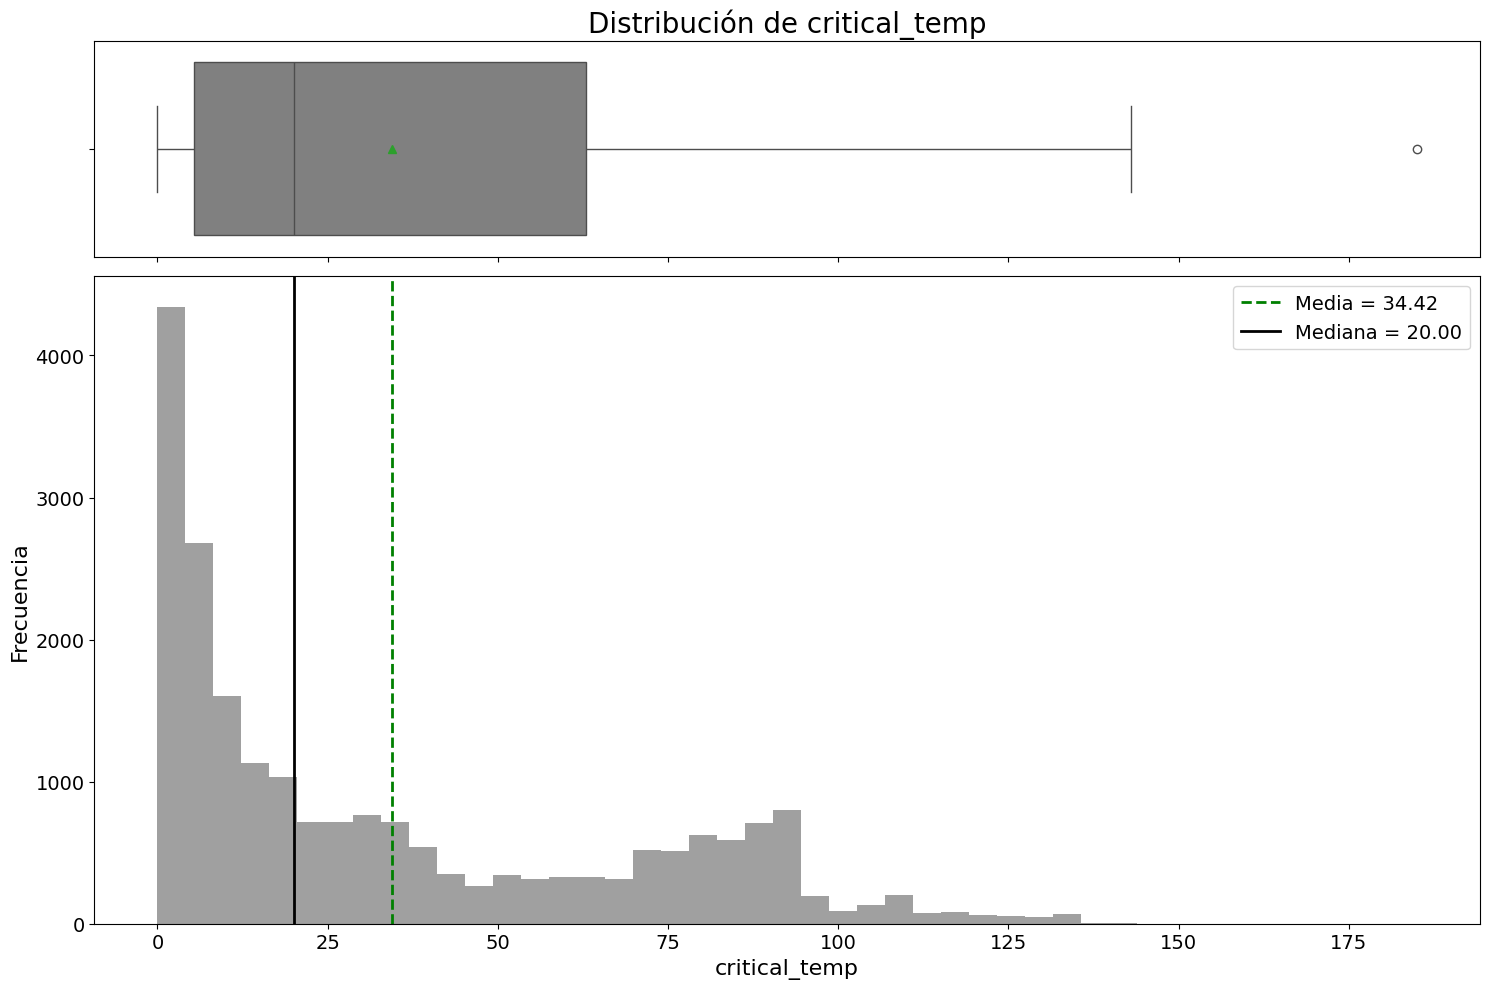

0.00021
185.0


In [47]:
histogram_boxplot(df['critical_temp'])

print(min(df['critical_temp']))
print(max(df['critical_temp']))

- La distribución esta sesgada a la derecha es decir, la mayor parte de los materiales tienen temperaturas críticas entre $\sim 0K$ y $\sim 50K$.
- Hay una cola larga, en la que vemos un claro descenso para materiales con temperaturas críticas por encima de $\sim 100K$
- La distribución refleja la realidad experimental: **los superconducotres de alta temperatura son excepcionales**.

El resultado es un dataset desbalanceado, no por errores de muestreo, si no por la realidad física de este fenómeno. Este desequilibrio deberá tenerse en cuenta durante el modelado, ya que los algoritmos tenderan a sesgarse y ajustar mejor los compuestos con temperaturas críticas bajas.

Para limitar el alcance de este problema, elegiremos cuidadosamente la función de pérdida y las metricas de validación a utilizar, prestando especial atención a la región de temperaturas críticas elevadas.

- Advertimos la presencia de un outlier con $T_C \sim 180\,K$. Normalemente pensaríamos que se trata de un error de medición pero dado el origen del dataset, investigamos a que material asignan tal temperatura crítica:

In [48]:
df.sort_values(by='critical_temp', ascending=False).head(10)

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
20573,2,16.536470,11.360293,5.685033,3.193745,0.136394,0.224622,31.05706,10.016373,15.528530,...,2.666667,2.449490,1.817121,0.410116,0.562335,5,1.333333,2.500000,2.357023e+00,185.0
3985,6,110.790067,53.779128,78.419756,34.814175,1.534148,1.685378,191.20060,12.543366,75.587235,...,2.041769,2.244924,2.029163,1.747868,1.416675,2,0.950860,0.745356,2.859955e-01,143.0
5200,6,110.790067,54.751013,78.419756,35.634607,1.534148,1.676546,191.20060,13.280875,75.587235,...,2.037500,2.244924,2.026163,1.747868,1.432405,2,0.925000,0.745356,2.712817e-01,143.0
19039,6,110.320617,52.533367,78.241067,34.005520,1.535695,1.653117,188.38390,13.796235,74.993418,...,2.047059,2.139826,2.038528,1.778233,1.377140,1,1.035294,0.372678,2.117647e-01,137.4
1343,7,106.454829,91.018475,78.774541,69.276239,1.709748,1.488831,192.98100,39.998760,71.393594,...,2.670330,2.869006,2.458852,1.855373,1.656659,3,0.934066,1.355262,1.231946e+00,136.0
1341,7,106.454829,90.979345,78.774541,69.263213,1.709748,1.577289,192.98100,35.405785,71.393594,...,2.648352,2.869006,2.446823,1.855373,1.727324,3,0.824176,1.355262,1.198659e+00,136.0
5476,5,91.508080,52.234821,64.570275,34.675999,1.327465,1.529741,184.59060,12.420128,68.009897,...,2.000000,2.000000,2.000000,1.609438,1.329205,0,0.920286,0.000000,4.440892e-16,135.8
7105,5,91.508080,54.627075,64.570275,35.612951,1.327465,1.534120,184.59060,12.156125,68.009897,...,2.000000,2.000000,2.000000,1.609438,1.353591,0,0.875000,0.000000,0.000000e+00,135.7
4709,5,91.508080,54.627075,64.570275,35.612951,1.327465,1.534120,184.59060,12.156125,68.009897,...,2.000000,2.000000,2.000000,1.609438,1.353591,0,0.875000,0.000000,0.000000e+00,135.5
5475,5,91.508080,52.281831,64.570275,34.710813,1.327465,1.529608,184.59060,12.436241,68.009897,...,2.000000,2.000000,2.000000,1.609438,1.330046,0,0.918886,0.000000,0.000000e+00,135.4


In [ ]:
du=pd.read_csv('../data/unique_m.csv')
du.loc[[20573]]

,H,He,Li,Be,B,C,N,O,F,Ne,...,Au,Hg,Tl,Pb,Bi,Po,At,Rn,critical_temp,material
20573,2.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,185.0,H2S1


El outlier corresponde a la $T_C$ del $H_2S$. Es conocido por la comunidad cientifica que ciertos compuestos, sometidos a unas condiciones de presión muy elevadas, pueden llegar a presentar superconductividad.

En definitiva, la $T_C=185\,K$ se corresponde con un outlier físico, pues existe el material con las propiedades descritas. Por este motivo y al no tratarse de un erro experimental, no eliminamos esta muestra del dataset.

#### _number\_of\_elements_
Dado que la variable _number\_of\_elements_ es discreta y solo tiene unos pocos valores enteros distintos, no tiene sentido representarla con un histograma continuo, en cambio se utiliza un gráfico de frecuencias. El uso de un diagrama de caja tampoco tiene sentido, dado que la variable no presenta valores extremos fuera del rango esperado.

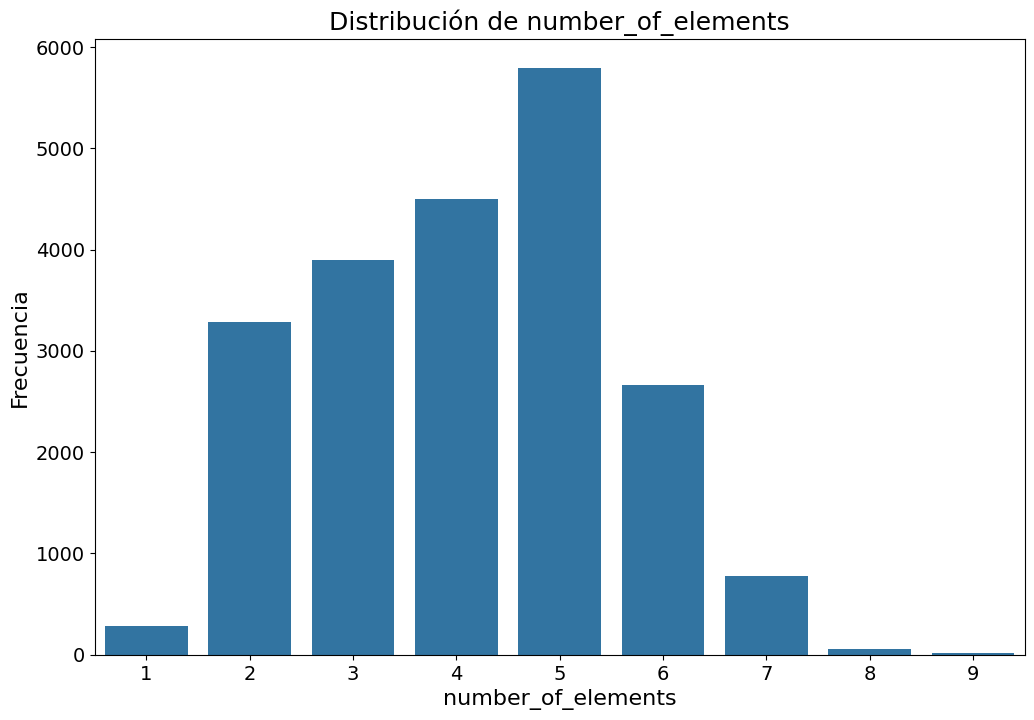

In [50]:
plt.figure(figsize=(12,8))
sns.countplot(x=df['number_of_elements'])
plt.title('Distribución de number_of_elements')
plt.xlabel("number_of_elements")
plt.ylabel("Frecuencia")
plt.show()

- El valor modal se encuentra en 5 elementos distintos es decir, los compuestos superconductores de 5 elementos son la clase mayoritaria en nuestro conjunto de datos.
- La distribución es claramente asimetrica, con frecuencias considerables y en aumento de 2 a 5, y un descenso importante a partir de 5. Los compuestos de 6 elementos distintos son todavía una clase considerablemente grande.
- Los superconductores de mas de 7 elementos, aunque existentes, son extremadamente raros. Esto mantiene cierta coherencia, pues las estructuras cristalinas formadas por tantos elementos suelen ser muy inestables.

#### _mean\_atomic\_mass_

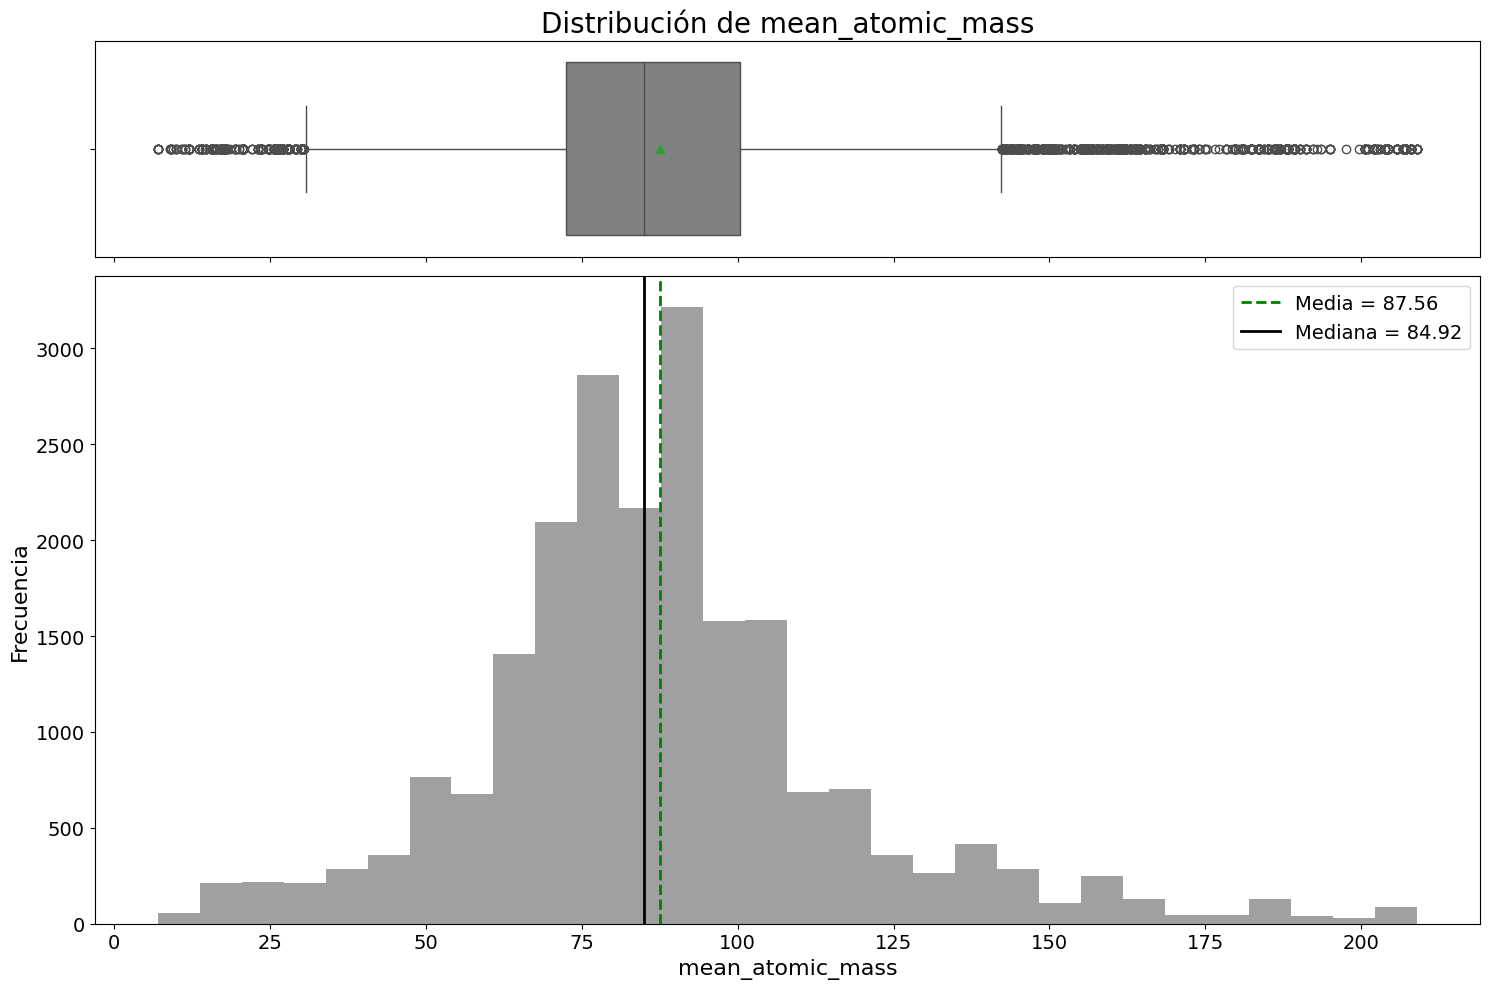

In [51]:
histogram_boxplot(df['mean_atomic_mass'], bins=30)

- Mayoría de valores comprendidos entre $\sim 60\,K$ y $\sim 110\,K$, lo que indica que la mayor parte de los superconductores tienen una masa atomica media en este rango.
- Media y mediana cercanas, lo que nos indica asimetría moderada, con cierto sesgo positivo.
- Aparecen outliers a ambos lados, aunque notamos una mayor presencia de estos en la parte derecha, fenomeno coherente con la presencia de elementos con masas atómicas elevadas.

#### _mean\_fie_

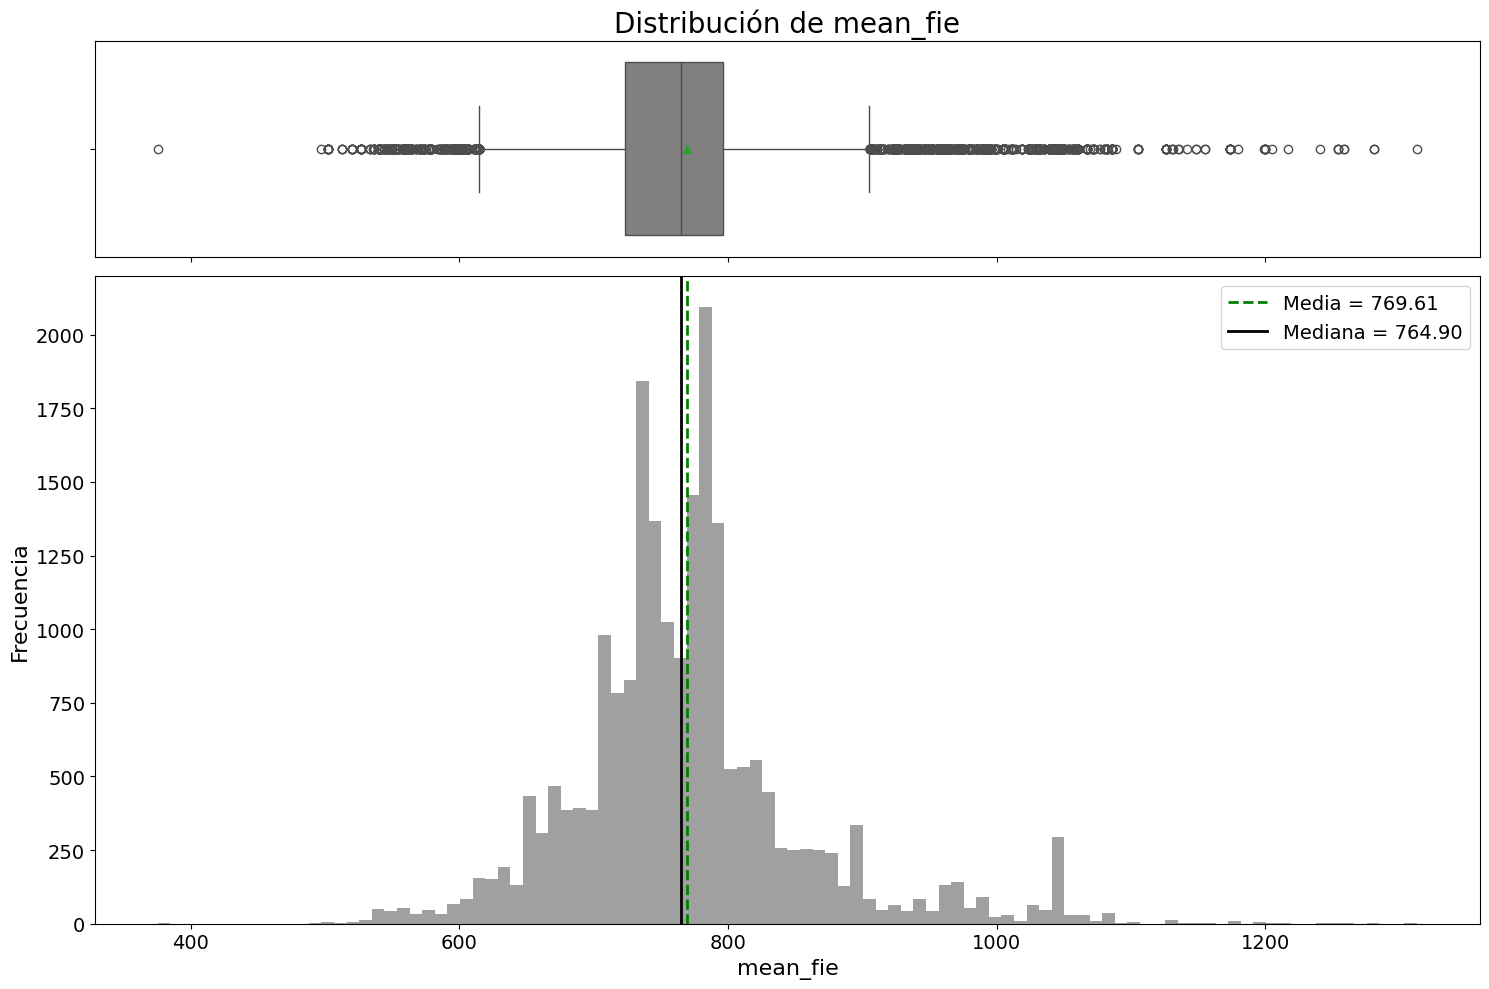

In [52]:
histogram_boxplot(df['mean_fie'], bins=100)

- La mayoría de los valores se encuentra entre $\sim 700\,kJ/mol$ y $\sim 900\,kJ/mol$.
- Media y mediana son próximas, lo que nos indica una asimetría leve, aunque se distingue cierto sesgo positivo.
- La presencia de outliers a ambos lados, aunque con valores mas extremos a la derecha, advierte de la presencia de compuestos altamente electropositivos y electronegativos respectivamente.
- La presencia de picos locales nos advierte la existencia de familias de compuestos con energías de ionización similares (compuestos por mismas familias de elementos).

#### _mean\_atomic\_radius_

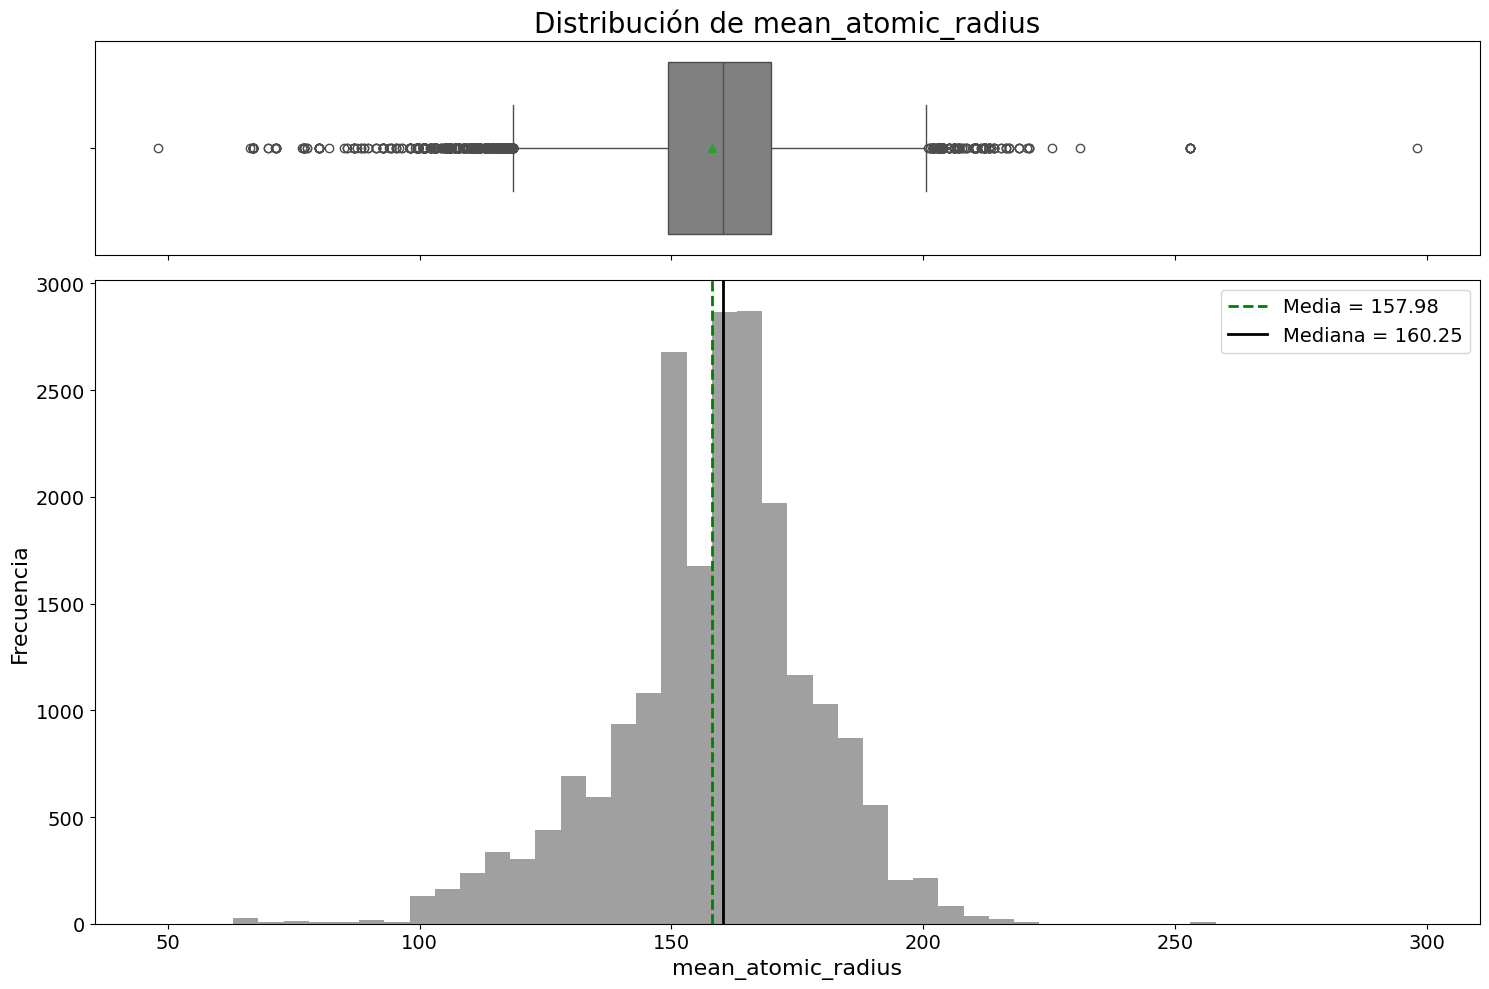

In [53]:
histogram_boxplot(df['mean_atomic_radius'], bins=50)

- La mayor parte de los valores se encuentran entre $\sim 130\,pm$ y $\sim 195\,pm$, la dispersión es moderada.
- Media y mediana ligeramente separadas, la distribución es levemente asimetrica hacia la izquierda.
- La presencia de outliers a ambos lados nos advierte de materiales formados por elementos muy pequeños, y muy grandes.

#### _mean\_Density_

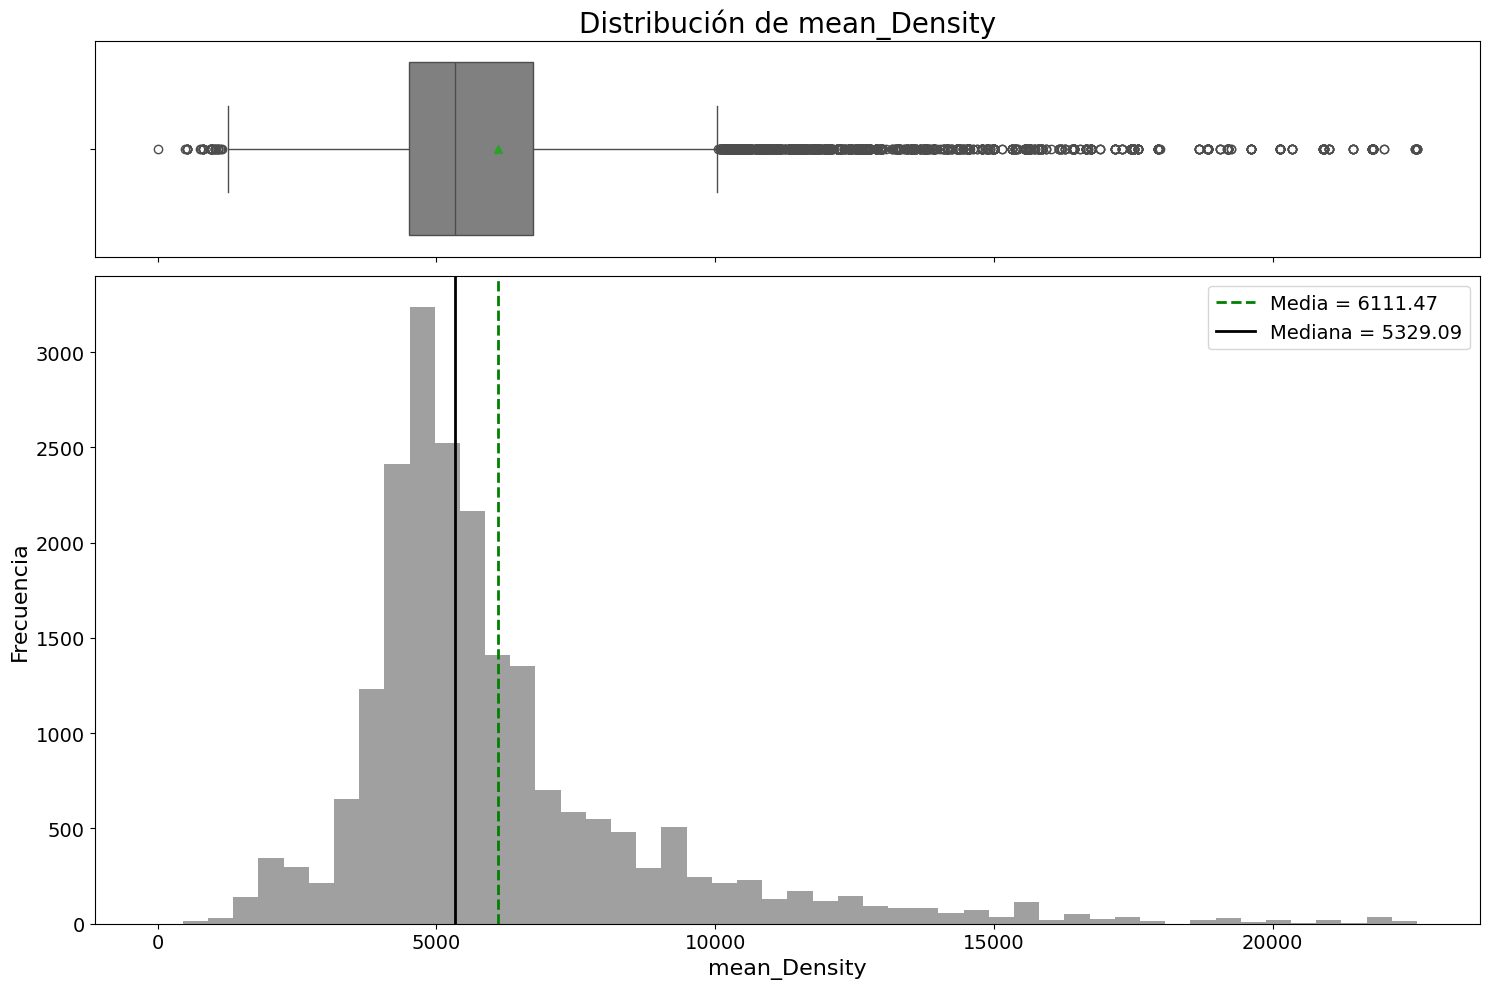

In [54]:
histogram_boxplot(df['mean_Density'], bins=50)

- La mayor parte de los valores se concentran entre $\sim 3000\,kg/m^3$ y $\sim 7000\,kg/m^3$, aunque se tiene una dispersión mas alta que en el resto de propiedades.
- Media y mediana notablemente separadas, distribución asimeterica hacia la derecha, derivada de un fuerte sesgo positivo. Este fenomeno se hace notable con la cola larga hacia la derecha, con valores que superan los $20000\,kg/m^3$.
- Se observan outliers, muy numerosos a densidades elevadas , que reflejan la presencia de elementos pesados. Los valores mas extremos corresponden a compuestos formados por metales pesados.

#### _mean\_ElectronAffinity_

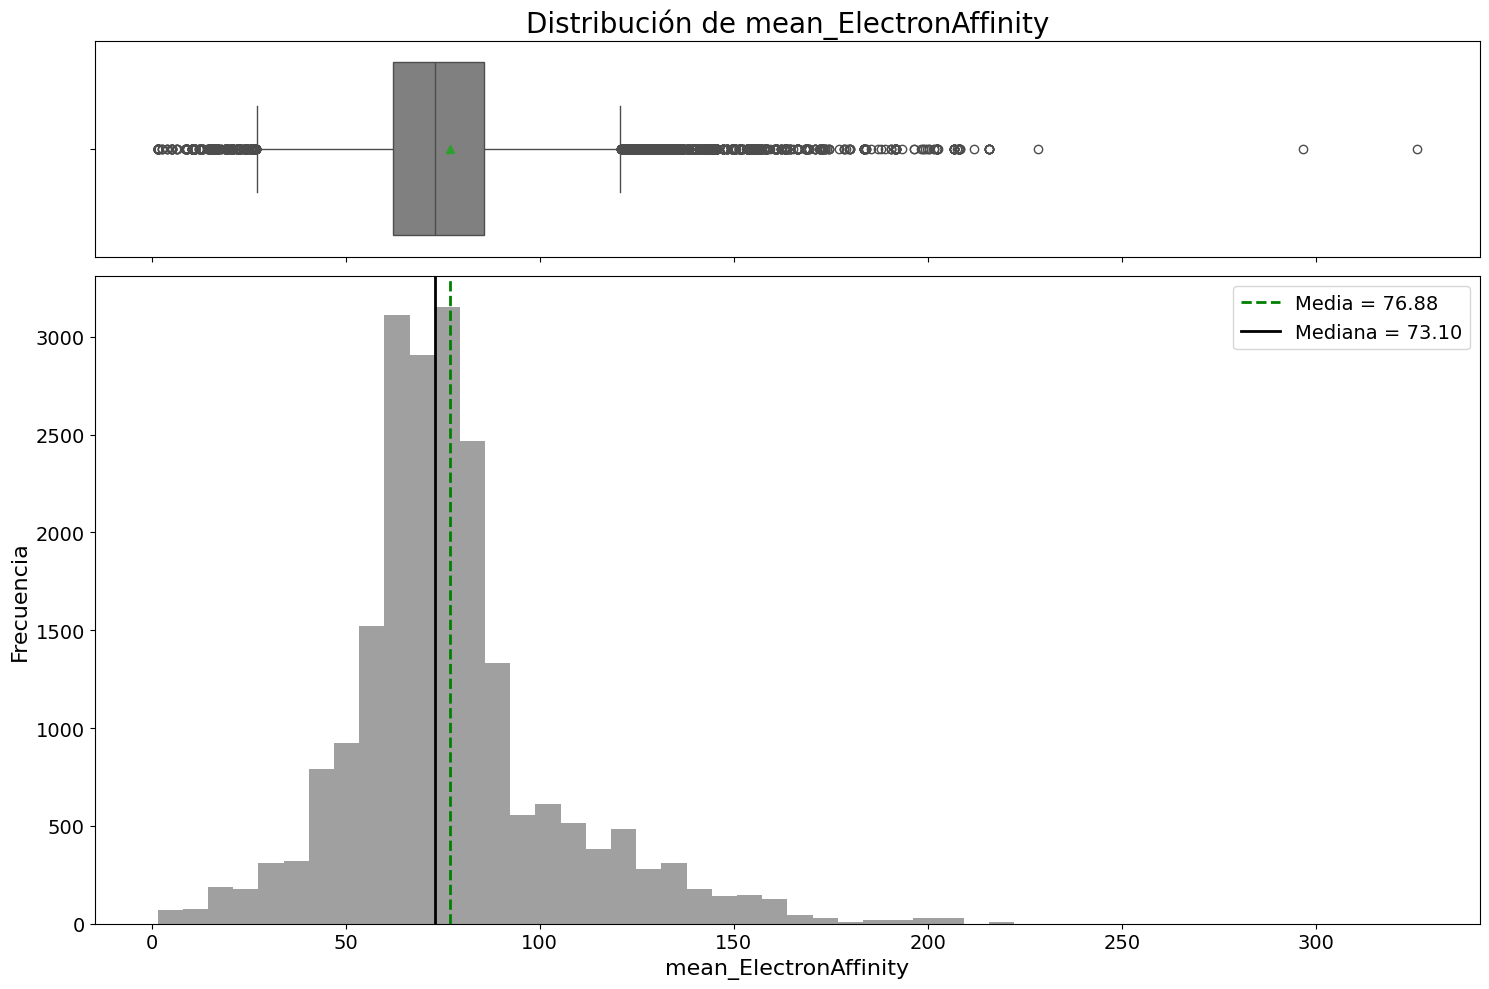

In [55]:
histogram_boxplot(df['mean_ElectronAffinity'], bins=50)

- Mayor concentración de valores entre $\sim 50\,kJ/mol$ y $\sim 90\,kJ/mol$. La dispersión más moderada nos indica cierta homogeneidad en el comportamiento medio de los materiales respecto a esta propiedad.
- Media y mediana ligeramente separadas, con una distribución asimetrica hacia la derecha, consecuencia de un sesgo positivo moderado. Caracterísitica que vemos reflejada en el histograma con una larga cola hacia la derecha, con algunos valores por encima de $300\,kJ/mol$.
- Outliers a ambos lados, mas numerosos y extremos del lado derecho, lo que de nuevo nos advierte la presencia de materiales formados por elementos muy electronegativos.

#### _mean\_FusionHeat_

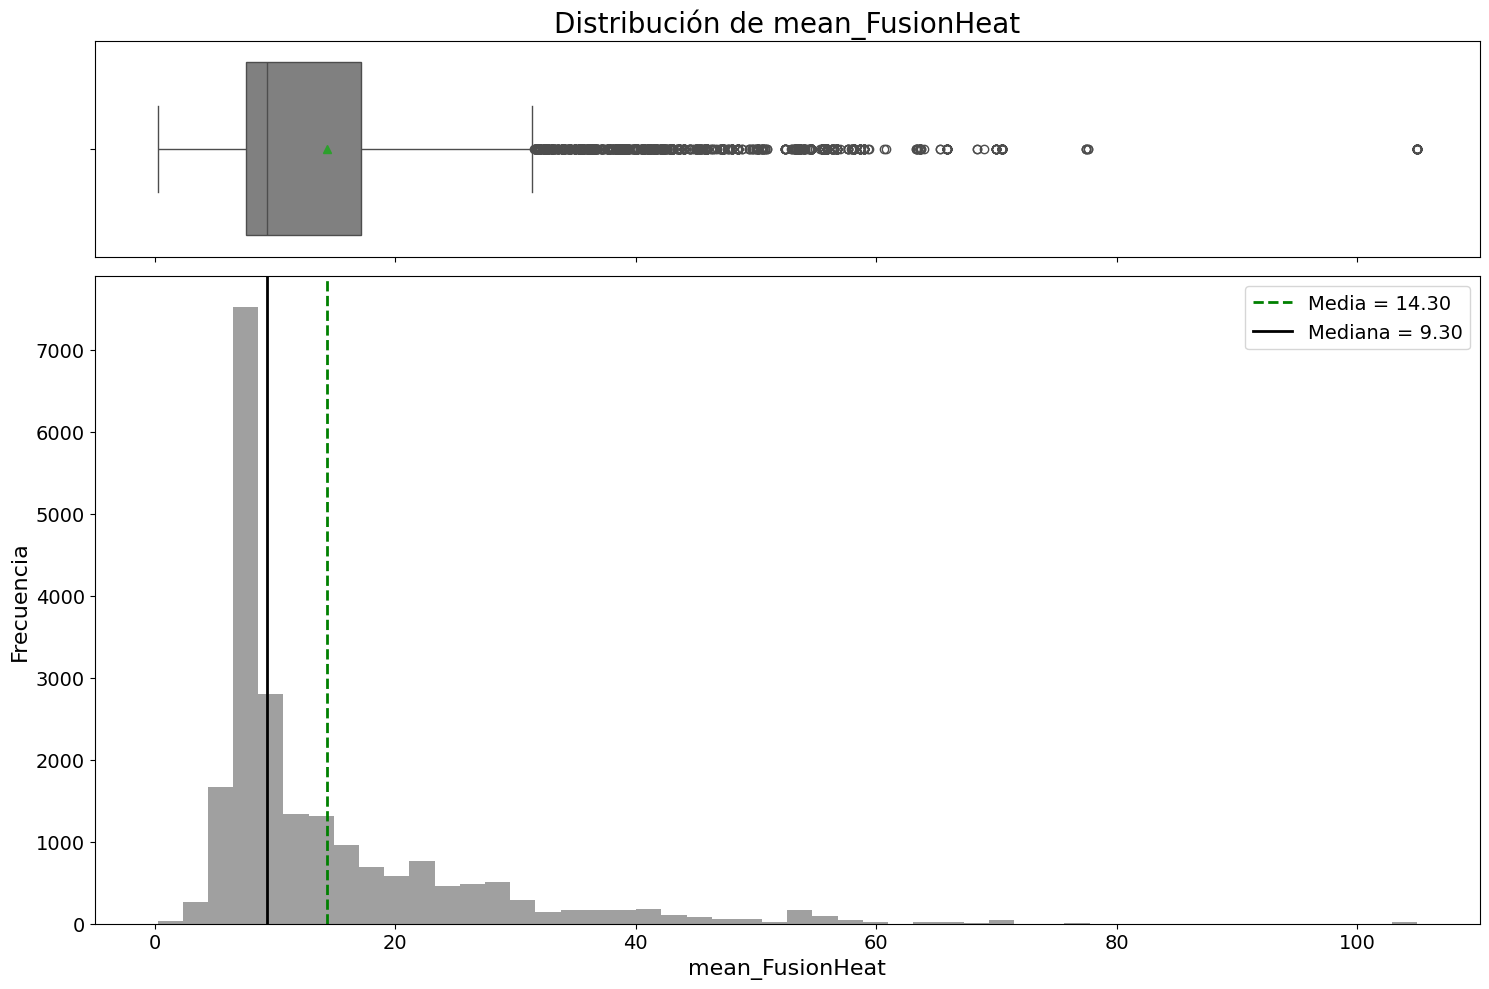

In [56]:
histogram_boxplot(df['mean_FusionHeat'], bins=50)

- La mayoría de los valores se encuentran por debajo de $\sim 15kJ/mol$. Esto sugiere que la mayoría de materiales en el conjunto de datos tienen estructuras de enlace moderadas.
- Se observa una mediana sensiblemente inferior a la media, como resultado de una distribución fuertemente asimetrica hacia la derecha. Confirmamos así un claro sesgo positivo.
- Se detectan outliers unicamente hacia el lado derecho, hacia donde se extiende una larga cola, con algún valor superando los $100\,kJ/mol$. Estos valores notablemente más altos corresponden con materiales que incluyen elementos con enlaces muy fuertes.

#### _mean\_ThermalConductivity_

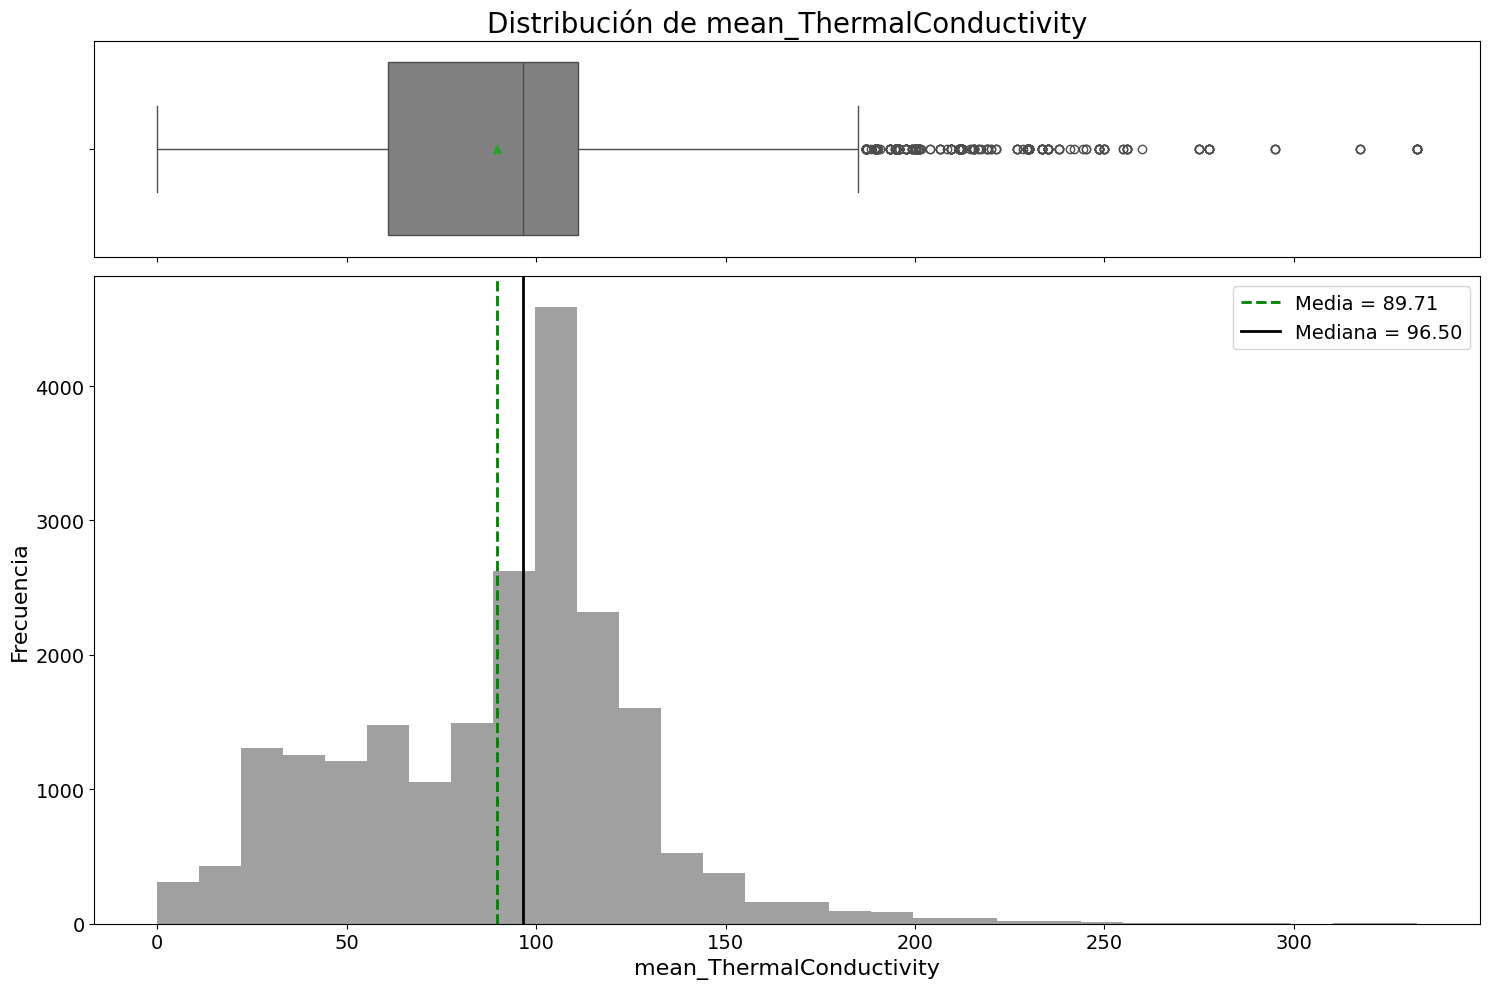

In [57]:
histogram_boxplot(df['mean_ThermalConductivity'], bins=30)

- Las frecuencias son moderadamente altas y en ligero aumento hasta alcanzar un máximo en $\sim 110\,W/(m \cdot K)$, luego disminuyen con rapidez. No obstante, la dispersion es notablemente alta, indicando una variabilidad significativa entre materiales con alta y baja conductividad.
- La media se encuentra ligeramente a la izquierda de la mediana, lo que confirma la asimetria hacia la izquierda que comentabamos. Esto refuerza la idea de cierto sesgo negativo.
- Se observan outliers para valores de conductividad altos, correspondientes a materiales con muy buena conduccion térmica.

#### _mean\_Valence_

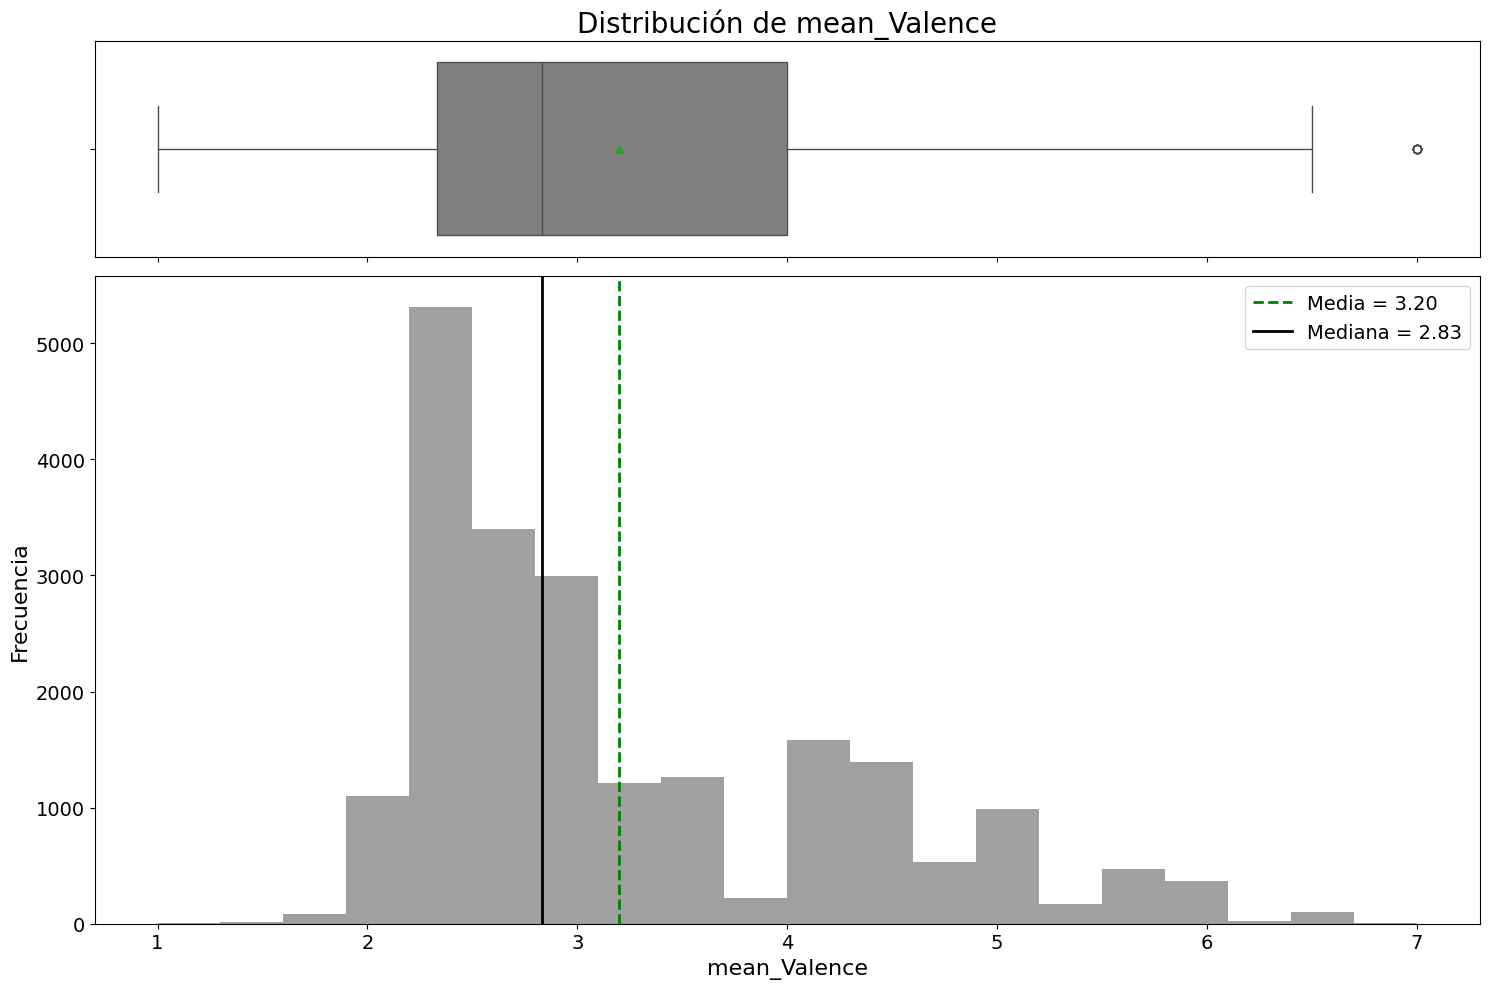

In [58]:
histogram_boxplot(df['mean_Valence'], bins=20)  

- Mayor parte de los valores concentrados entre $2$ y $3.5$.
- La media esta relativamente por encima de la derecha como consecuencia de una distribución asimetrica hacia la derecha. Esto es consecuencia de un moderado sesgo positivo, pues hay un aumento rapido, alcanzando el máximo y un descenso más progresivo.
- Se observa un outlier aislado con valencia media cercana a $7$ que vamos a investigar de que compuesto se trata.

In [59]:
df.sort_values('mean_Valence', ascending=False).head(10)

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
15771,1,186.20700,186.207000,186.207000,186.207000,0.000000,0.000000,0.000,0.000000,0.0000,...,7.0000,7.000000,7.000000,0.000000,0.000000,0,0.0000,0.0,0.000000,1.695
16026,1,186.20700,186.207000,186.207000,186.207000,0.000000,0.000000,0.000,0.000000,0.0000,...,7.0000,7.000000,7.000000,0.000000,0.000000,0,0.0000,0.0,0.000000,1.700
15831,1,186.20700,186.207000,186.207000,186.207000,0.000000,0.000000,0.000,0.000000,0.0000,...,7.0000,7.000000,7.000000,0.000000,0.000000,0,0.0000,0.0,0.000000,1.694
13587,1,126.90447,126.904470,126.904470,126.904470,0.000000,0.000000,0.000,0.000000,0.0000,...,7.0000,7.000000,7.000000,0.000000,0.000000,0,0.0000,0.0,0.000000,1.200
12490,1,186.20700,186.207000,186.207000,186.207000,0.000000,0.000000,0.000,0.000000,0.0000,...,7.0000,7.000000,7.000000,0.000000,0.000000,0,0.0000,0.0,0.000000,1.696
10165,1,186.20700,186.207000,186.207000,186.207000,0.000000,0.000000,0.000,0.000000,0.0000,...,7.0000,7.000000,7.000000,0.000000,0.000000,0,0.0000,0.0,0.000000,1.703
12489,1,186.20700,186.207000,186.207000,186.207000,0.000000,0.000000,0.000,0.000000,0.0000,...,7.0000,7.000000,7.000000,0.000000,0.000000,0,0.0000,0.0,0.000000,7.000
17858,2,188.21850,186.421426,188.207751,186.419263,0.693090,0.211241,4.023,166.142908,2.0115,...,6.9467,6.480741,6.942722,0.690186,0.186675,1,6.3071,0.5,0.224631,1.934
17857,2,141.08350,186.143827,133.672823,186.120611,0.641090,0.003221,90.247,186.009483,45.1235,...,6.9993,6.480741,6.999245,0.690186,0.005051,1,6.9909,0.5,0.026448,1.694
17856,2,185.02350,186.204633,185.019715,186.204618,0.693127,0.007819,2.367,185.836953,1.1835,...,6.9990,6.480741,6.998921,0.690186,0.006911,1,6.9870,0.5,0.031607,1.723


In [60]:
du.loc[[15771]]

,H,He,Li,Be,B,C,N,O,F,Ne,...,Au,Hg,Tl,Pb,Bi,Po,At,Rn,critical_temp,material
15771,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,0.0,0.0,0,0,0,1.695,Re1


El outlier corresponde con el $Re$, metal de transición y superconductor tipo I. Adopta comunmente estados de oxidación altos como $7$.

Los valores extremos en este conjunto no son errores experimentales, sino fenómenos reales dentro de la física de la superconductividad. Por tanto eliminarlos implicaría perder información física valiosa de comportamientos excepcionales pero posibles.

Los modelos de árboles no se ven significativamente afectados por la presencia de estos valores extremos, pues las divisiones durante el entrenamiento se basan en umbrales para descriptores concretos.

In [ ]:
#Separamos caracteristicas y variable objetivo
X=df.drop(columns=['critical_temp'])
y=df['critical_temp']

#Dividimos el dataset en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (17010, 81) Test: (4253, 81)


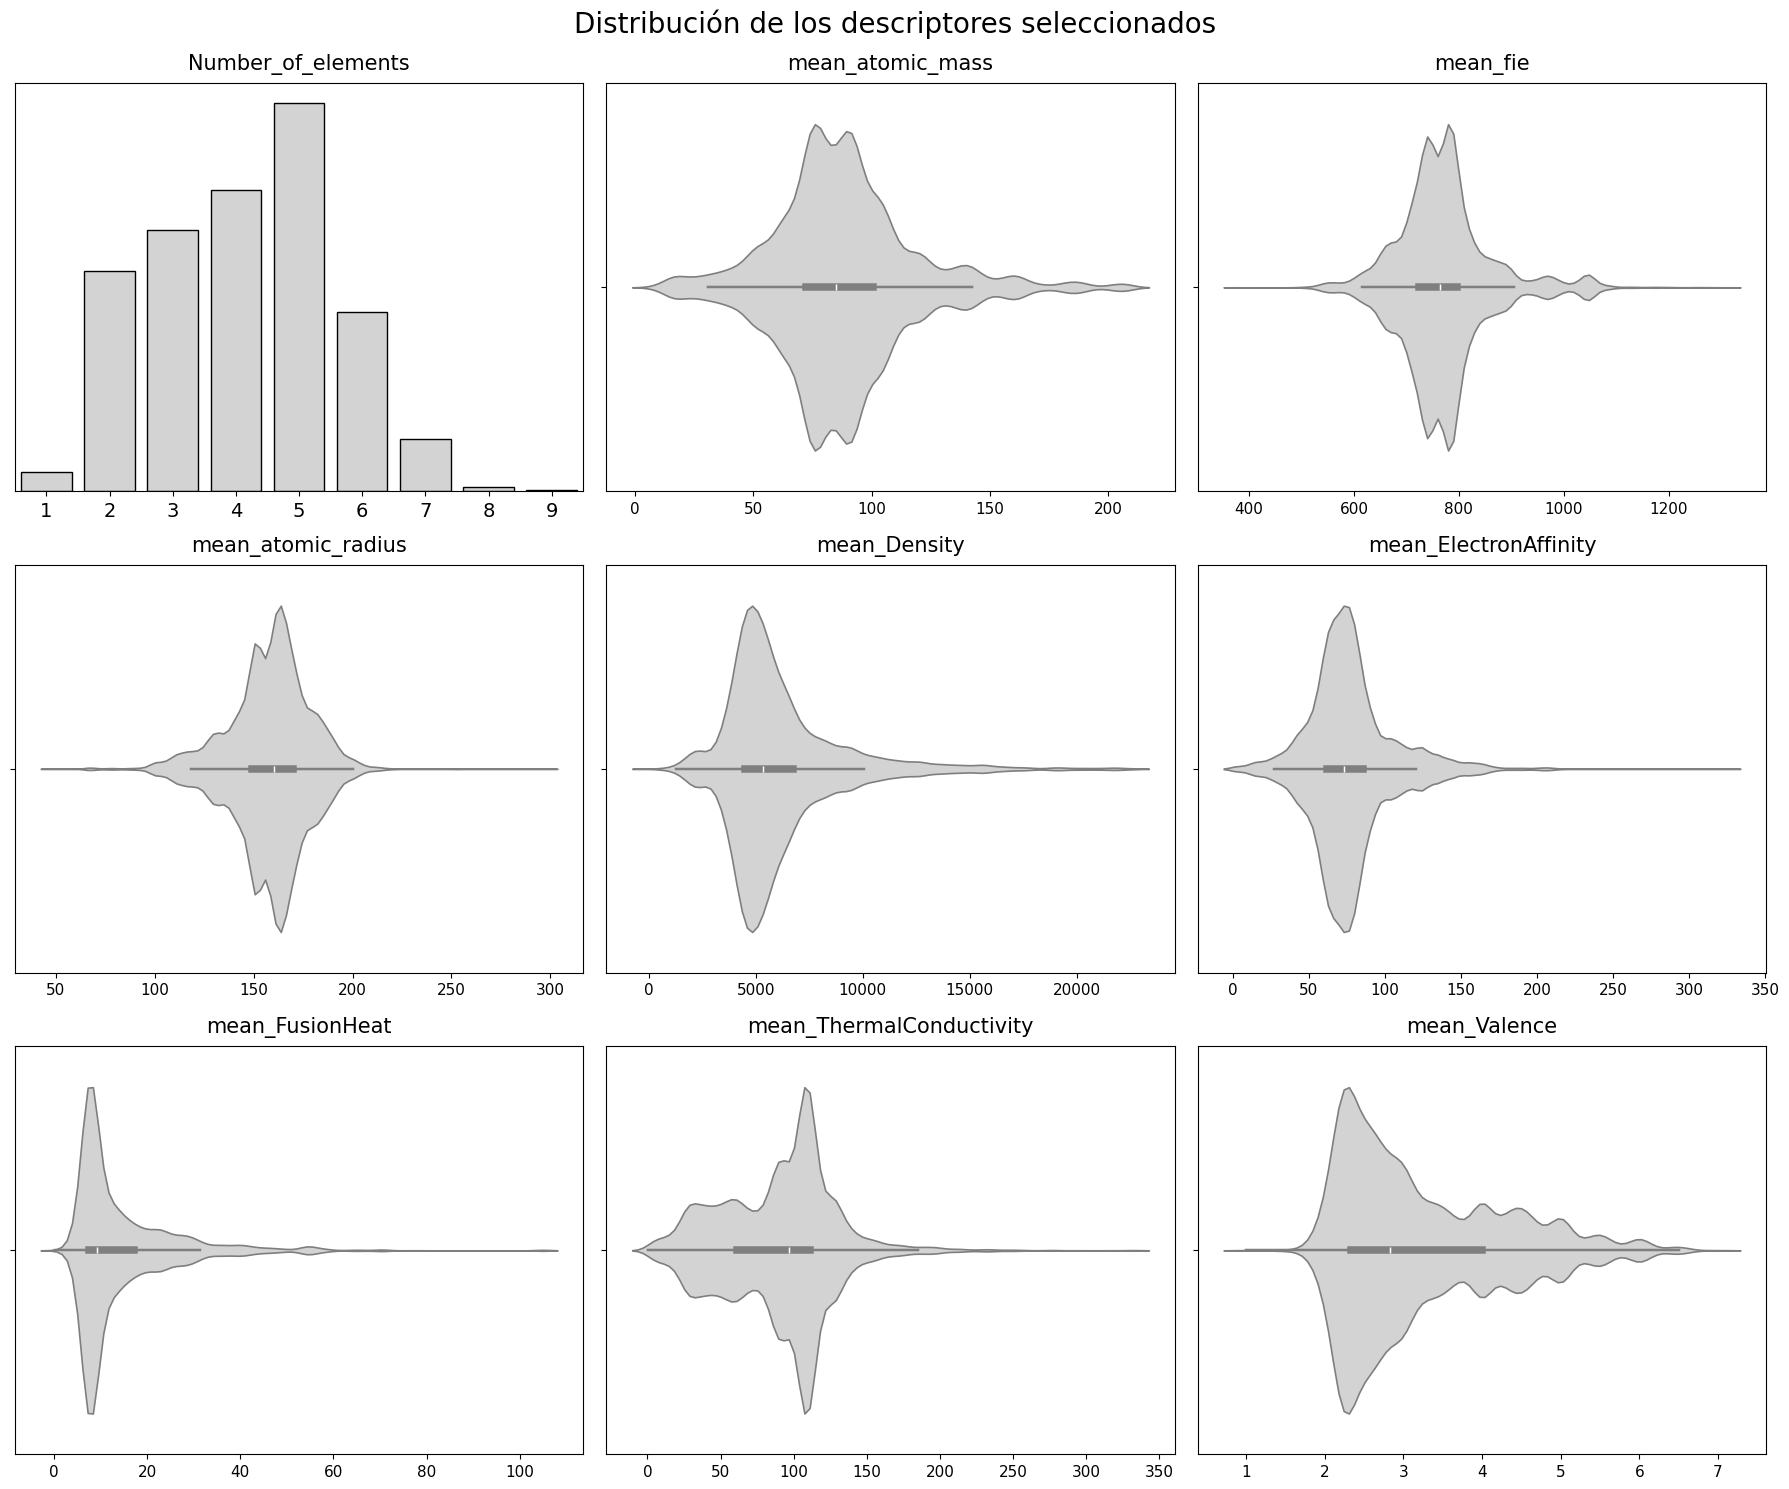

In [ ]:
def violin_grid_with_count(X, figsize=(18, 15)):
    """
    Muestra un grid 3x3 con:
      - Countplot para number_of_elements
      - Violinplots horizontales con boxplots internos para las variables mean_*
    """
    # =============================
    # Selección de columnas
    # =============================
    features = ['number_of_elements'] + [col for col in X.columns if col.startswith('mean_')]
    features = features[:9]  # limitar a 9

    # =============================
    # Configuración del grid
    # =============================
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    axes = axes.flatten()

    # =============================
    # Primer gráfico: countplot
    # =============================
    sns.countplot(
        x=X['number_of_elements'],
        ax=axes[0],
        color="lightgray",
        edgecolor="black"
    )
    axes[0].set_title("Number_of_elements", fontsize=15, pad=10)
    axes[0].set_xlabel("", fontsize=13)
    axes[0].set_ylabel("", fontsize=13)
    axes[0].tick_params(axis='y', left=False,  labelleft=False)

    # =============================
    # Resto de variables: violines
    # =============================
    for i, col in enumerate(features[1:], start=1):
        sns.violinplot(
            x=X[col],
            ax=axes[i],
            color="lightgray",
            inner="box",
            linewidth=1.2,
            orient="h"
        )
        axes[i].set_title(col, fontsize=15, pad=10)
        axes[i].set_xlabel("", fontsize=13)
        axes[i].set_ylabel("", fontsize=13)
        axes[i].tick_params(axis='both', labelsize=11)

    fig.suptitle("Distribución de los descriptores seleccionados",
             fontsize=20, y=0.99)
    # Eliminar subplots vacíos si hay menos de 9
    for j in range(len(features), 9):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# =============================
# Ejemplo de uso
# =============================
violin_grid_with_count(X)


### Análisis bivariante
En esta etapa se analizan de forma conjunta la variable objetivo (critical_temp) y las variables predictoras principales, con el propósito de identificar posibles relaciones de dependencia entre ellas.

Este estudio permite observar cómo varía la temperatura crítica en función de las distintas propiedades atómicas y estructurales de los materiales, y detectar tendencias o patrones físicos que podrían explicar su comportamiento.

Iniciamos por una exploración visual particularizada para cada una de las variables explicativas escojidas para el analisis univariable, comprobando la dependencia de cada propiedad con la variable objetivo.

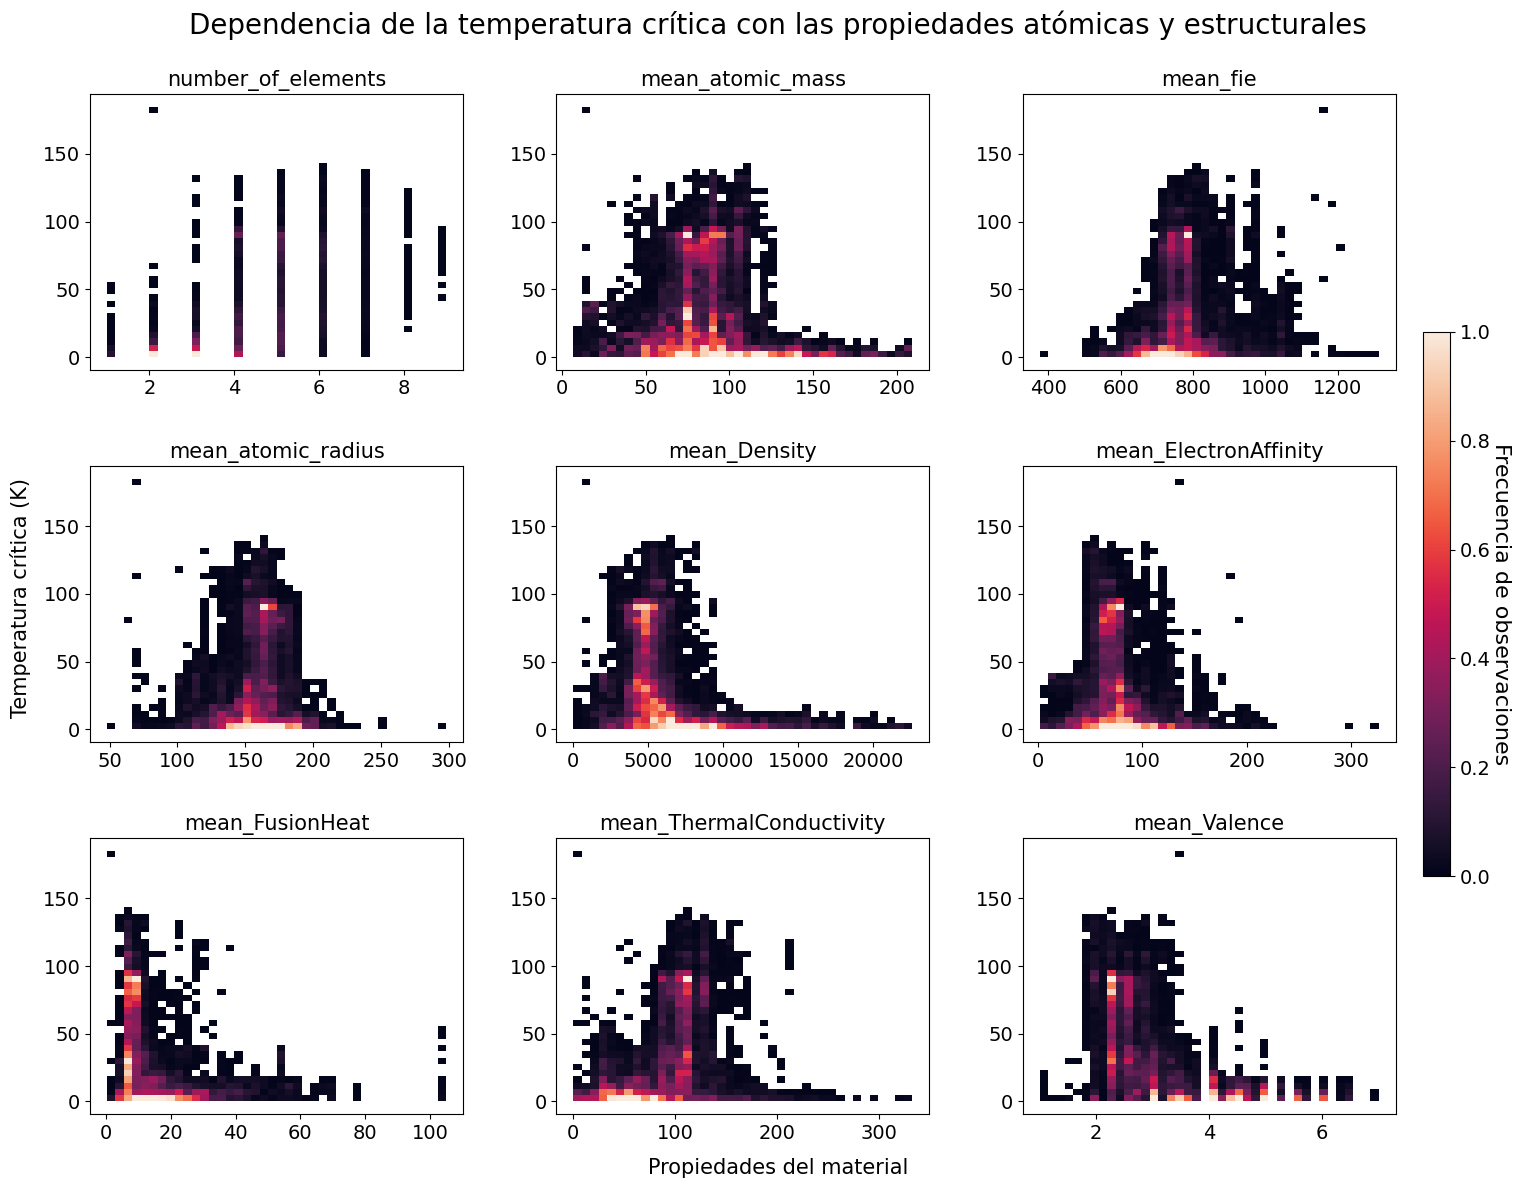

In [ ]:
# Variables principales
features = [
    "number_of_elements",
    "mean_atomic_mass",
    "mean_fie",
    "mean_atomic_radius",
    "mean_Density",
    "mean_ElectronAffinity",
    "mean_FusionHeat",
    "mean_ThermalConductivity",
    "mean_Valence"
]

# Crear figura
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
cmap = 'rocket'

for i, col in enumerate(features):
    ax = axes[i]

    # Histplot (2D heatmap)
    sns.histplot(
        x=df[col],
        y=df["critical_temp"],
        bins=40,            # resolución
        pmax=0.9,           # recorta valores extremos
        cmap=cmap,
        cbar=False,
        ax=ax
    )

    ax.set_title(col, fontsize=15)
    ax.set_xlabel("")
    ax.set_ylabel("")

# === Ajustar márgenes manualmente ===
fig.subplots_adjust(
    left=0.07,   # espacio para etiqueta Y
    right=0.92,  # espacio para colorbar
    bottom=0.07, # espacio para etiqueta X
    top=0.92,
    wspace=0.25,
    hspace=0.35
)

# === Etiquetas globales ===
fig.text(0.5, 0.02, 'Propiedades del material', ha='center', fontsize=15)
fig.text(0.02, 0.5, 'Temperatura crítica (K)', va='center', rotation='vertical', fontsize=15)
fig.suptitle("Dependencia de la temperatura crítica con las propiedades atómicas y estructurales",
             fontsize=20, y=0.99)

# === Barra de color global ===
norm = plt.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label('Frecuencia de observaciones', rotation=270, labelpad=15)

plt.show()


- No se observan relaciones lineales claras entre las propiedades atómicas individuales y loa tempratura crítica. El fenómeno superconductor depende de interacciones no lineaes y multivariantes.
- Si se identifican zonas de concentración local en las que aparecen los compuestos con temperaturas más críticas. Esto ocurren en general en las regiones en las que se encuentran la mayor parte del conjunto de datos (tanto de baja como de alta temperatura crítica). Las altas temperaturas críticas ocurren en subconjuntos específicos dentro de los rangos más comunes.
- La aparición de estos patrones justifica la utilización de modelos de aprendizaje por conjuntos, capaces de caputrar interacciones complejas entre múltiples variables.

Vamos a proceder a representar la matriz de correlación. Para ello vamos a separar el prodecimiento en dos partes, primero representaremos solo es subconjunto _mean\_*_ de propiedades, de esta forma podemos observar relaciones generales entre las distintas propiedades.
De momento vamos a obviar relaciones dentro de la familia de una propiedad y de otros subconjuntos entre ellos y con la variable objetivo.

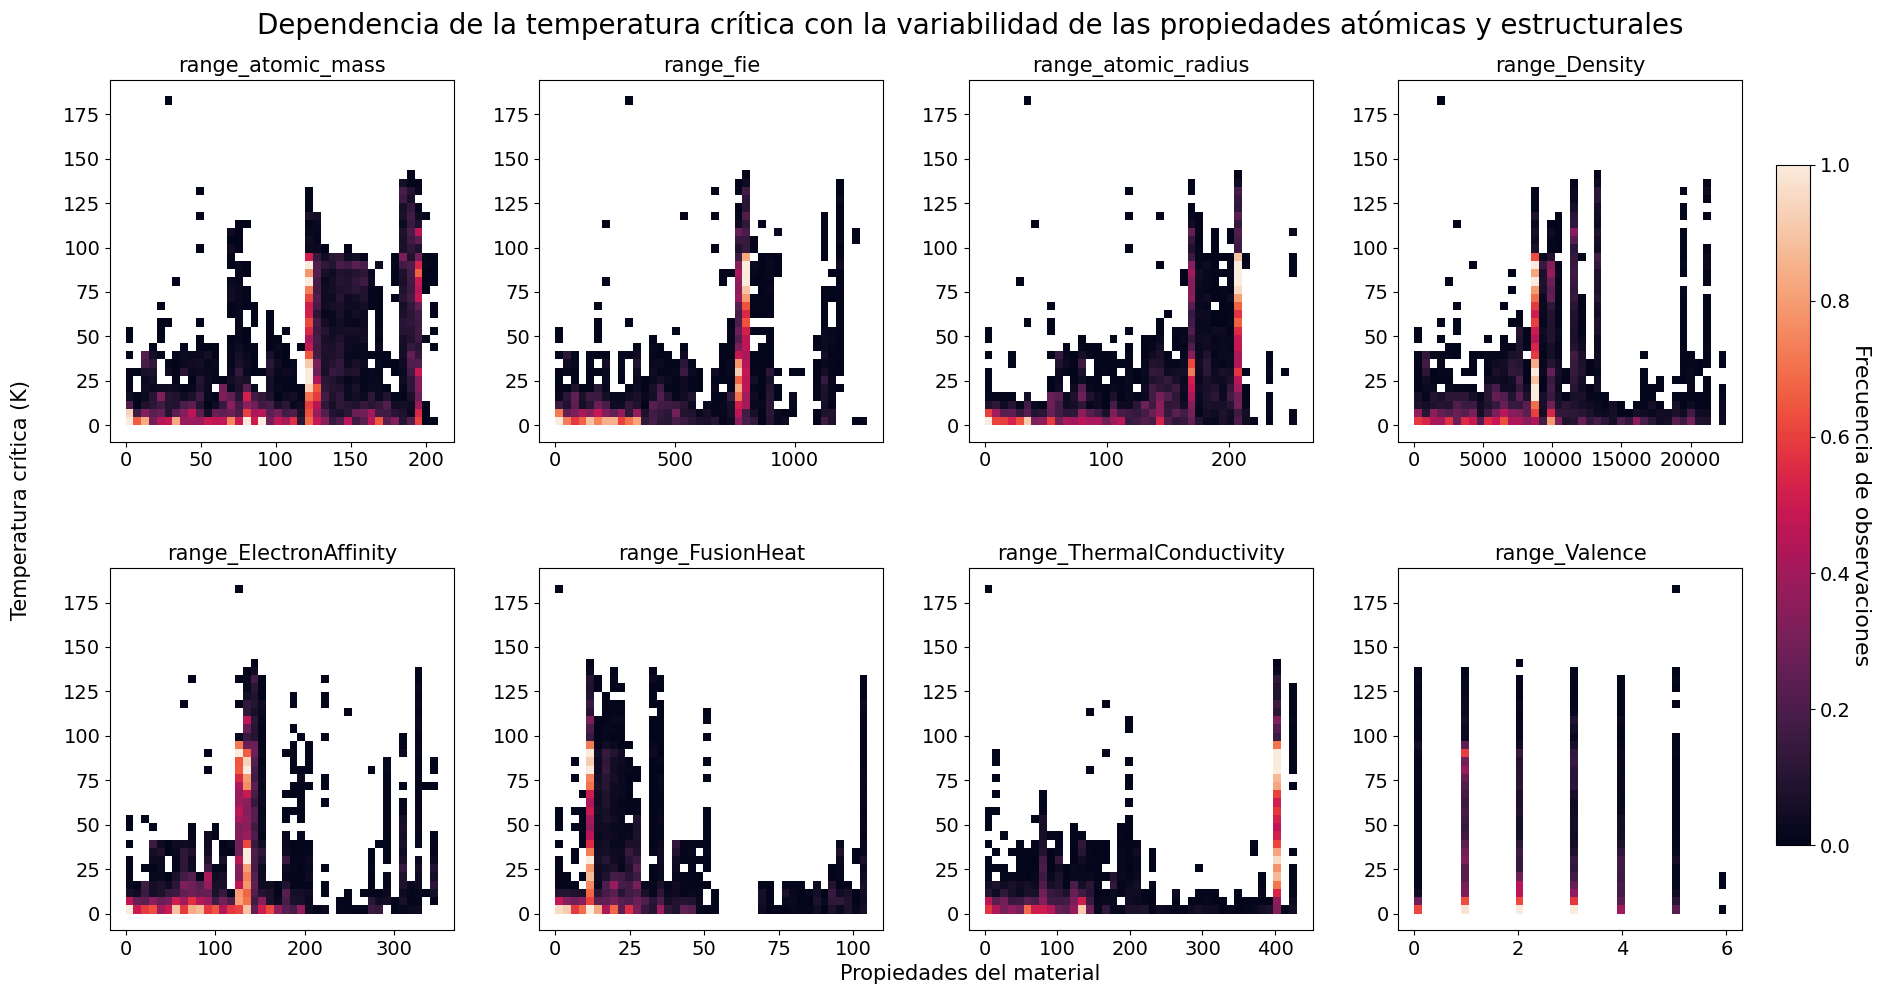

In [ ]:
# Variables principales
features = [
    "range_atomic_mass",
    "range_fie",
    "range_atomic_radius",
    "range_Density",
    "range_ElectronAffinity",
    "range_FusionHeat",
    "range_ThermalConductivity",
    "range_Valence"
]

# Crear figura
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
cmap = 'rocket'

for i, col in enumerate(features):
    ax = axes[i]

    # Histplot (2D heatmap)
    sns.histplot(
        x=df[col],
        y=df["critical_temp"],
        bins=40,            # resolución
        pmax=0.9,           # recorta valores extremos
        cmap=cmap,
        cbar=False,
        ax=ax
    )

    ax.set_title(col, fontsize=15)
    ax.set_xlabel("")
    ax.set_ylabel("")

# === Ajustar márgenes manualmente ===
fig.subplots_adjust(
    left=0.07,   # espacio para etiqueta Y
    right=0.92,  # espacio para colorbar
    bottom=0.07, # espacio para etiqueta X
    top=0.92,
    wspace=0.25,
    hspace=0.35
)

# === Etiquetas globales ===
fig.text(0.5, 0.02, 'Propiedades del material', ha='center', fontsize=15)
fig.text(0.02, 0.5, 'Temperatura crítica (K)', va='center', rotation='vertical', fontsize=15)
fig.suptitle("Dependencia de la temperatura crítica con la variabilidad de las propiedades atómicas y estructurales",
             fontsize=20, y=0.99)

# === Barra de color global ===
norm = plt.Normalize(vmin=0, vmax=1)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.02, pad=0.02)
cbar.set_label('Frecuencia de observaciones', rotation=270, labelpad=15)

plt.show()


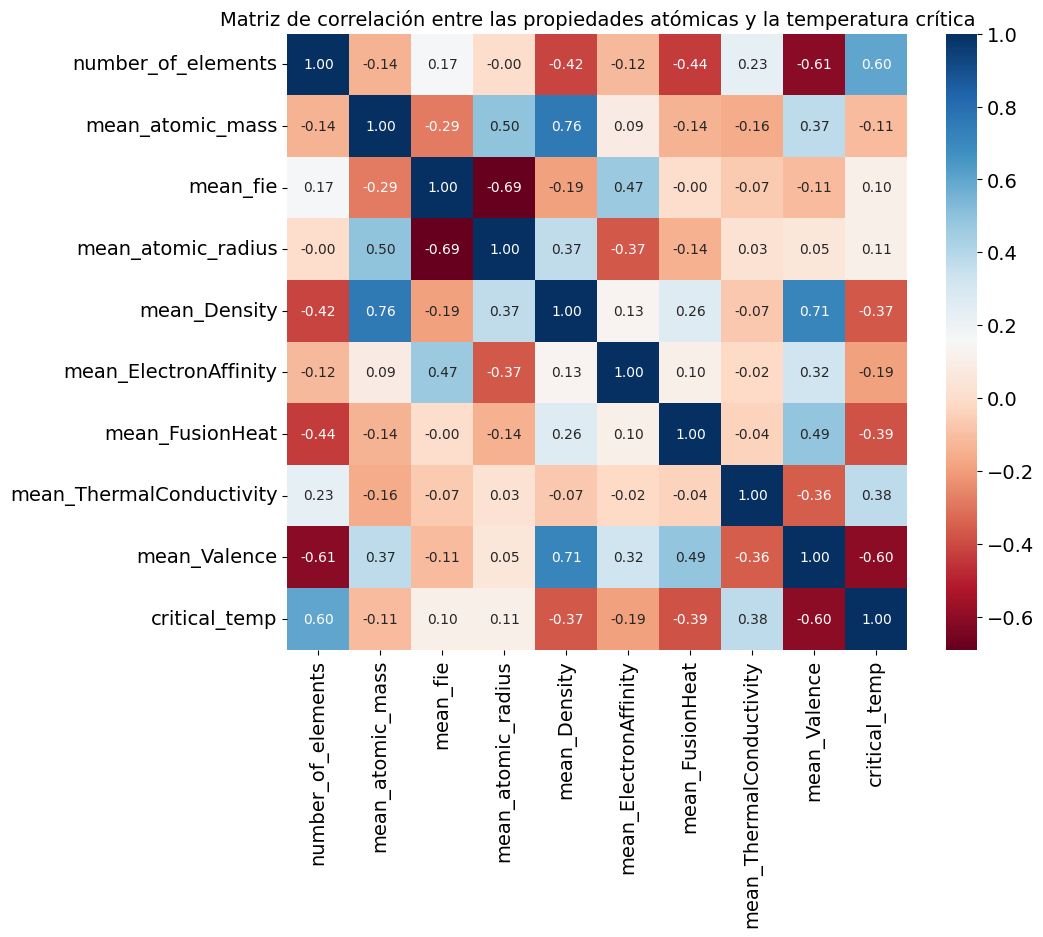

In [65]:
# Visualizar solo un subconjunto (por ejemplo las 9 mean_*)
corr = df.corr()
subset_cols = [
    "number_of_elements",
    "mean_atomic_mass", "mean_fie", "mean_atomic_radius",
    "mean_Density", "mean_ElectronAffinity", "mean_FusionHeat",
    "mean_ThermalConductivity", "mean_Valence", "critical_temp"
]
plt.figure(figsize=(10, 8))
sns.heatmap(df[subset_cols].corr(), annot=True, fmt=".2f", cmap="RdBu", cbar=True)
plt.title("Matriz de correlación entre las propiedades atómicas y la temperatura crítica", fontsize=14)
plt.show()

- Correlación negativa entre _number\_of\_elements_ y _mean\_valence_: a mayor número de elementos distintos en un compuesto, la valencia suele tender a disminuir a valores más intermedios. Esto explica igual la correlación negativa con _mean\_Density_ y _mean\_FusionHeat, pues redes cristalinas más complejas presentan menor cohesión estructural, lo que se tradude en menor densidad y en que la energía necesaria para romper los enlaces atómicos sea menor.
- Correlación positiva entre _mean\_atomic\_mass_, _mean\_atomic\_radius_ y _mean\_Density_, lo que muestra coherencia física entre las propiedades.
- Correlacion positiva entre _mean\_fie_ y _mean\_ElectronAffinity_: a más afinidad electrónica, el elemento es más electonegativo y, en consecuencia, requiere mas energía para ser ionizado (retirar su electrón más externo).
- Correlación negativa entre _mean\_atomic\_radius_ y _mean\_fie_/_mean\_ElectronAffinity_: cuanto mayor es el tamaño del atomo, menor es la atracción entre el núcleo y los electrones externos, de modo que se necesita menos energía para ionizarlo y su afinidad electrónica también disminuye.
- Corelación positiva y notablemente alta entre _mean\_valence_ y _mean\_density_: los elementos con valencias más elevadas suelen participar en enlaces más fuertes, lo que da lugar a estructuras más compactas.

Con la variable objetivo _critical\_temp_ podemos distinguir propiedades con correlaciones notables:
- Notablemente positiva $(0.6)$ con _number\_of\_elements_: compuestos más complejos tienden a alcanzar mayores temperaturas críticas.
- MOderadamente positiva $(0.38)$ con _mean\_ThermalConductivity_: sugiere que cierto nivel de conductividad térmica podria estar asociado a una mayor temperatura crítica.
- Moderadamente negativa $(\sim -0.38)$ con _mean\_Density_ y _mean\_FusionHeat_: estructuras menos cohesionadas o menos densas pueden favorecer el fenómeno superconductor.
- Considerablemente negativa $(-0.6)$ con _mean\_valence_: compuestos con mayor número de electrones de enlace promedio tienden a tener menores temperaturas críticas.


A continuación obtenemos la matriz de correlación que incluye todas las variables del conjunto de datos. Notar que efecto de la gran cantidad de descriptores, se pierde detalle anivel individual, pero podemos identificar patrones globales de dependencia entre grupos de variables.

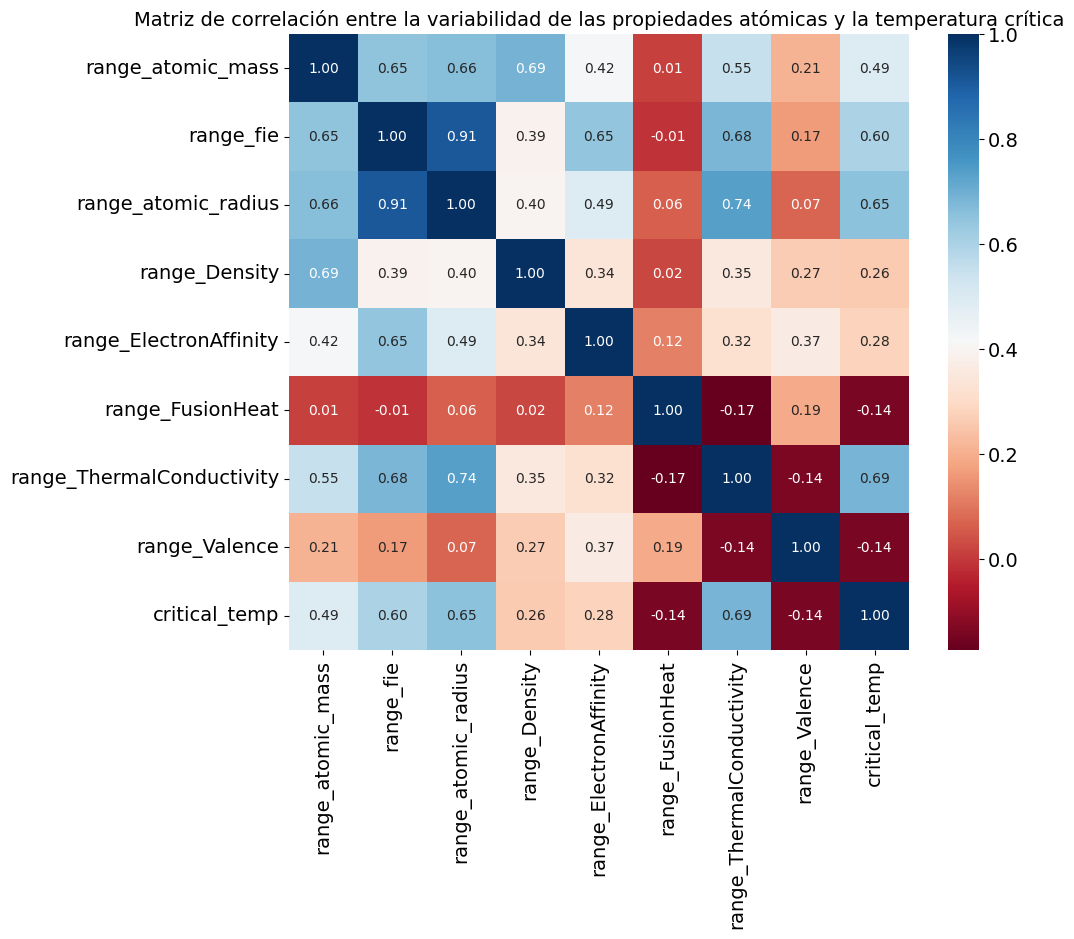

In [66]:
# Visualizar solo un subconjunto (por ejemplo las 9 mean_*)
corr = df.corr()
subset_cols = [
     "range_atomic_mass",
    "range_fie",
    "range_atomic_radius",
    "range_Density",
    "range_ElectronAffinity",
    "range_FusionHeat",
    "range_ThermalConductivity",
    "range_Valence",
    "critical_temp"
]
plt.figure(figsize=(10, 8))
sns.heatmap(df[subset_cols].corr(), annot=True, fmt=".2f", cmap="RdBu", cbar=True)
plt.title("Matriz de correlación entre la variabilidad de las propiedades atómicas y la temperatura crítica", fontsize=14)
plt.show()

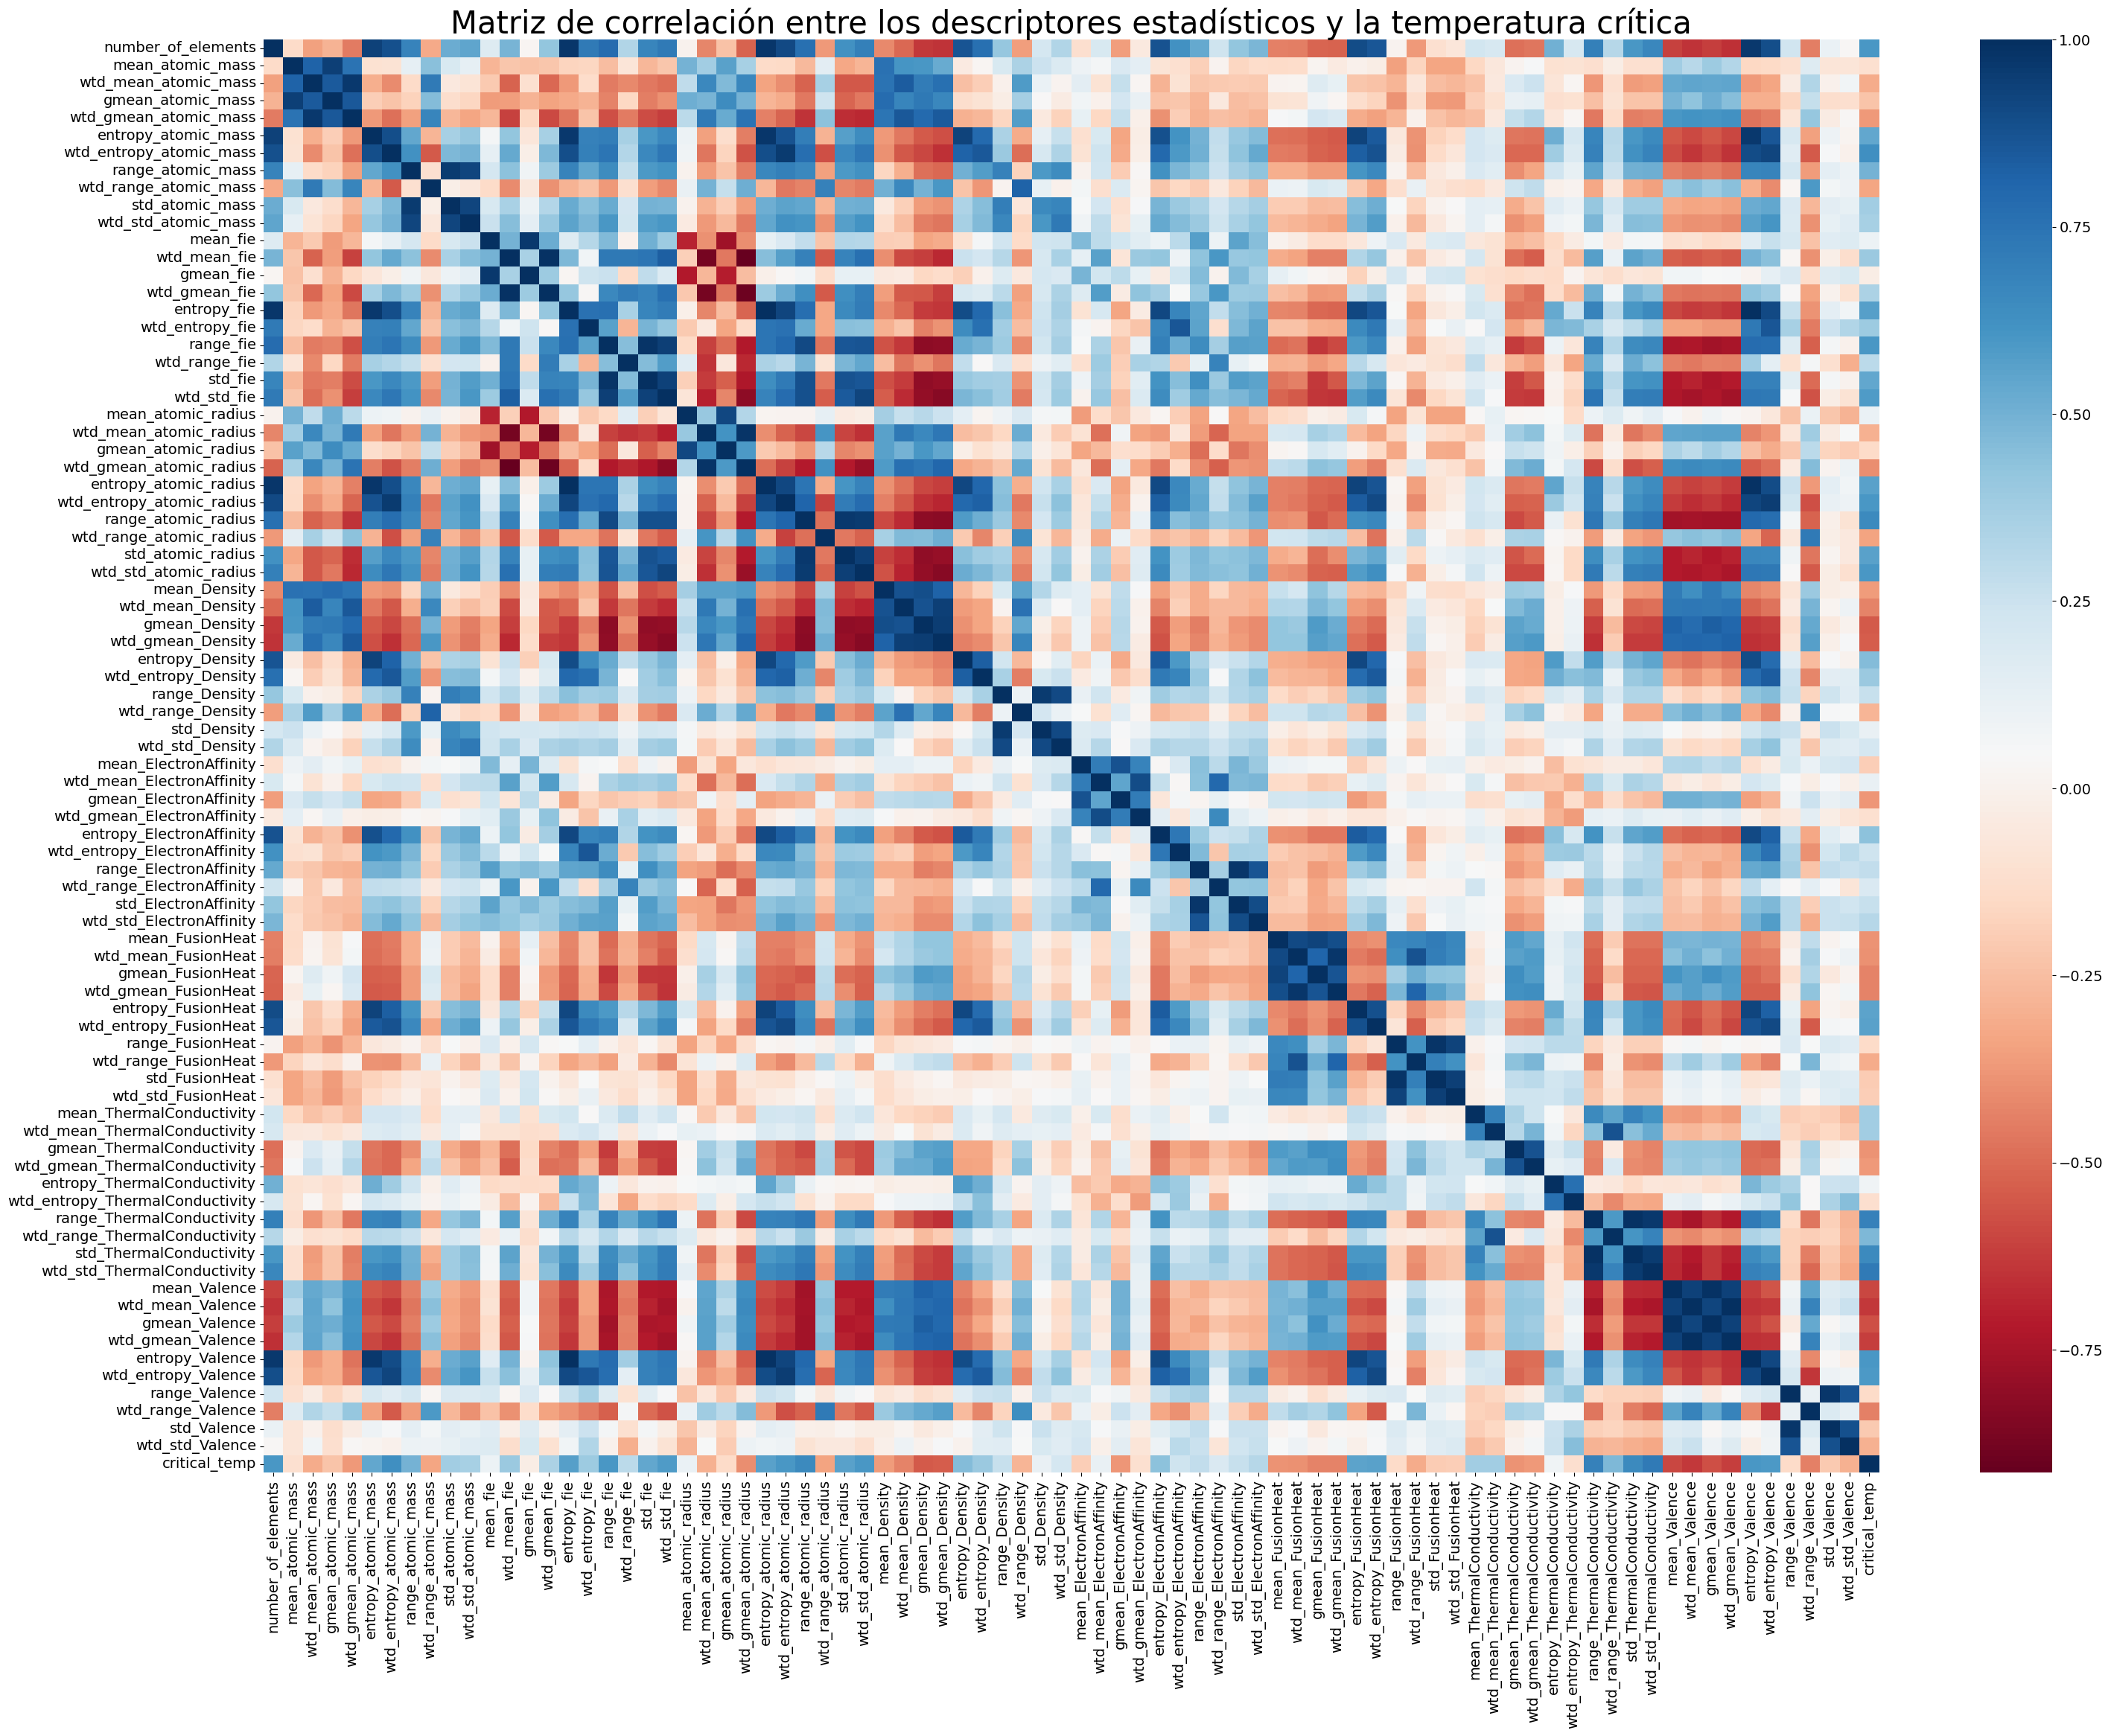

In [67]:
# Calcular la matriz de correlación completa
plt.figure(figsize=(35, 25))
sns.heatmap(df.corr(), annot=False, fmt=".2f", cmap="RdBu", cbar=True)
plt.title("Matriz de correlación entre los descriptores estadísticos y la temperatura crítica", fontsize=30)
plt.show()

- Lo más notable que vamos a distinguir es una estructura de bloques muy marcada. Se observan regiones cuadradas y simetricas (en particular de tamaño 4x4), que se repiten a lo largo de la diagonal principa, pero también fuera de ella. 
- Cuando aparecen estos bloques fuera de la diagonal prinicpal, corresponden a las distintas familias de medias (_mean\_\*_, _wtd\_mean_\*, _gmean\_\*, _wtd\_gmean\_\*_) de una misma propiedad, relacionandose con las familias equivalentes de otra propiedad. Esto indica una correlación notable entre dos magnitudes físicas distintas, reflejando patrones similares a los observados en la matriz reducida de la familia de medias aritmeticas.
- Los bloques sobre la diagonal principal representan la autocorrelación interna de cada grupo de descriptores derivados de una misma magnitud. Esto nos confirma la redundancia existente entre las distintas metricas empleadas.
- Algunas relaciones que no resultaban evidentes durante el analisis reducido de la familia _mean\_\*_, aparecen ahora al considerar las familias _range\_\*_ y _std\_\*_. Estas correlaciones nos indican que, para ciertos materiales, la dispersión y el rango de los valores atómicos tambien se vinculan con otras propiedades.
- También se observa el refuerzo de correlaciones ya identificadas en el abnalisis previo, que crecen al incluir nuevos estimadores.

En conjunto se evidencia que el conjunto de datos contiene alta multicolinealidad entre familias derivadas de una misma magnitud, pero también diversidad informativa entre propiedades diferentes.

Los modelos de conjuntos basados en arboloes que se utilizaran posteriormente son capaces de gestionar internamente la redundancia y seleccionan las caracterísiticas más relevantes durante el entrenamiento.

In [ ]:
# =============================
# Configuración y funciones
# =============================

# Validación cruzada
cv = KFold(n_splits=2, shuffle=True, random_state=42)

def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# Scorers personalizados
scoring = {
    'r2': 'r2',
    'rmse': 'neg_root_mean_squared_error',
    'mape': 'neg_mean_absolute_percentage_error',
    'smape': make_scorer(smape, greater_is_better=False)
}

# =============================
# Modelos
# =============================
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=200, learning_rate=0.1)
}

# =============================
# Evaluación
# =============================
results = {}
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {
        "R² medio": np.mean(scores['test_r2']),
        "RMSE medio": -np.mean(scores['test_rmse']),
        "MAPE medio (%)": -np.mean(scores['test_mape'])*100,
        "sMAPE medio (%)": -np.mean(scores['test_smape'])
    }

# =============================
# Resultados ordenados por RMSE
# =============================
df_results = pd.DataFrame(results).T.sort_values(by="RMSE medio")
print("Resultados de validación cruzada (5 folds):")
display(df_results.round(3))


Resultados de validación cruzada (5 folds):


,R² medio,RMSE medio,MAPE medio (%),sMAPE medio (%)
XGBoost,0.909,10.383,820.425,33.677
Random Forest,0.908,10.438,811.522,29.207
Decision Tree,0.839,13.765,766.195,32.947


In [ ]:
# =============================
# Definición de modelos
# =============================
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1
)

# =============================
# Entrenamiento
# =============================
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# =============================
# Predicciones
# =============================
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

# =============================
# Métricas
# =============================
def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    )

def safe_mape(y_true, y_pred, eps=10.0):
    mask = y_true > eps
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

results_test = {
    "Random Forest": {
        "R²": r2_score(y_test, y_pred_rf),
        "RMSE": root_mean_squared_error(y_test, y_pred_rf),
        "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred_rf) * 100,
        "sMAPE (%)": smape(y_test, y_pred_rf),
        "safeMAPE (%)": safe_mape(y_test, y_pred_rf)
    },
    "XGBoost": {
        "R²": r2_score(y_test, y_pred_xgb),
        "RMSE": root_mean_squared_error(y_test, y_pred_xgb),
        "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred_xgb) * 100,
        "sMAPE (%)": smape(y_test, y_pred_xgb),
        "safeMAPE (%)": safe_mape(y_test, y_pred_xgb)
    }
}

df_test_results = pd.DataFrame(results_test).T.round(3)
print("Resultados en conjunto de test (escala Kelvin):")
display(df_test_results)

NameError: name 'RandomForestRegressor' is not defined

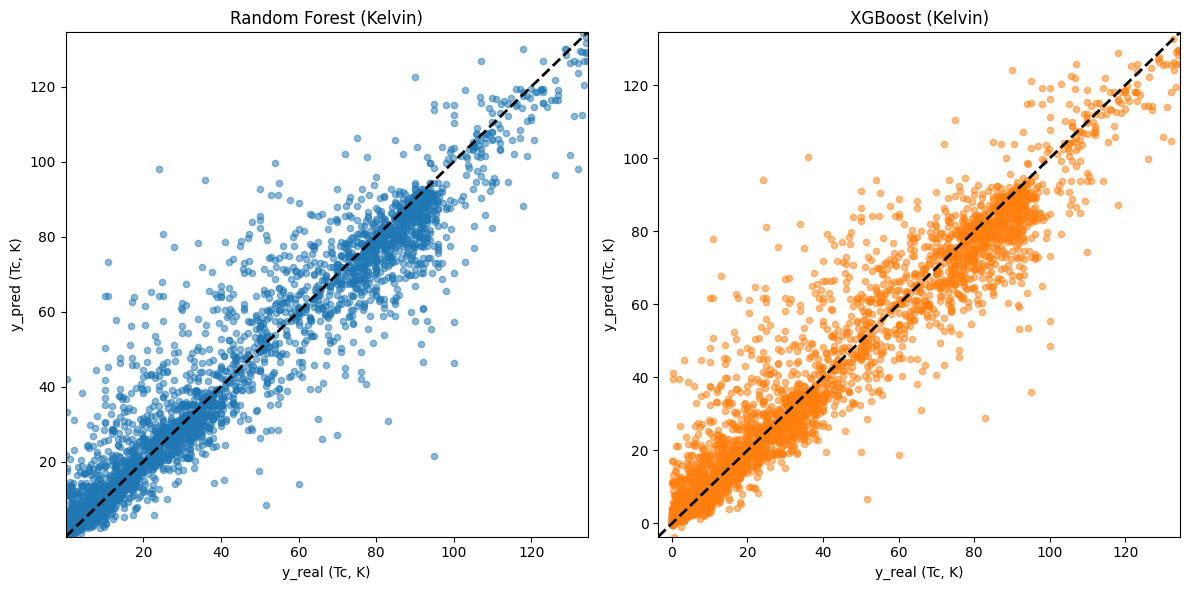

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Random Forest (Kelvin)
axes[0].scatter(y_test, y_pred_rf, alpha=0.5, s=20, color="tab:blue")
lims = [min(y_test.min(), y_pred_rf.min()), max(y_test.max(), y_pred_rf.max())]
axes[0].plot(lims, lims, 'k--', lw=2)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_title("Random Forest (Kelvin)")
axes[0].set_xlabel("y_real (Tc, K)")
axes[0].set_ylabel("y_pred (Tc, K)")

# XGBoost (Kelvin)
axes[1].scatter(y_test, y_pred_xgb, alpha=0.5, s=20, color="tab:orange")
lims = [min(y_test.min(), y_pred_xgb.min()), max(y_test.max(), y_pred_xgb.max())]
axes[1].plot(lims, lims, 'k--', lw=2)
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_title("XGBoost (Kelvin)")
axes[1].set_xlabel("y_real (Tc, K)")
axes[1].set_ylabel("y_pred (Tc, K)")

plt.tight_layout()
plt.show()


In [ ]:
# =============================
# Random Forest - búsqueda aleatoria
# =============================
param_dist_rf = {
    'n_estimators': randint(200, 1000),
    'max_depth': [None] + list(range(5, 30, 5)),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)
search_rf.fit(X_train, y_train)
best_rf = search_rf.best_estimator_
print("Mejores hiperparámetros RF:", search_rf.best_params_)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Mejores hiperparámetros RF: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 720}
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Mejores hiperparámetros XGB: {'colsample_bytree': np.float64(0.610167650697638), 'learning_rate': np.float64(0.031578285398660894), 'max_depth': 9, 'n_estimators': 942, 'reg_alpha': np.float64(0.47537022318211175), 'reg_lambda': np.float64(1.1265511439527673), 'subsample': np.float64(0.878206434570451)}


In [ ]:
# =============================
# XGBoost - búsqueda aleatoria
# =============================
param_dist_xgb = {
    'n_estimators': randint(200, 1000),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_lambda': uniform(0, 2),
    'reg_alpha': uniform(0, 1)
}

xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)

search_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)
search_xgb.fit(X_train, y_train)
best_xgb = search_xgb.best_estimator_
print("Mejores hiperparámetros XGB:", search_xgb.best_params_)

In [ ]:
from sklearn.model_selection import GridSearchCV

# =============================
# Grid de Random Forest
# =============================
param_grid_rf = {
    'n_estimators': [600, 720, 800],
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [5, 8, 12],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)



# =============================
# Ajuste de ambos modelos
# =============================
print("----- GridSearch Random Forest -----")
grid_rf.fit(X_train, y_train)
best_rf_grid = grid_rf.best_estimator_
print("Mejores hiperparámetros RF (GridSearch):", grid_rf.best_params_)


----- GridSearch Random Forest -----
Fitting 3 folds for each of 324 candidates, totalling 972 fits
Mejores hiperparámetros RF (GridSearch): {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 720}


In [ ]:
# =============================
# Grid de XGBoost
# =============================
param_grid_xgb = {
    'n_estimators': [800, 900, 1000],
    'learning_rate': [0.02, 0.03, 0.05],
    'max_depth': [8, 9, 10],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.6, 0.7],
    'reg_alpha': [0.4, 0.5, 0.6],
    'reg_lambda': [1.0, 1.2]
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42, objective="reg:squarederror", n_jobs=-1),
    param_grid=param_grid_xgb,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)


print("\n----- GridSearch XGBoost -----")
grid_xgb.fit(X_train, y_train)
best_xgb_grid = grid_xgb.best_estimator_
print("Mejores hiperparámetros XGB (GridSearch):", grid_xgb.best_params_)


----- GridSearch XGBoost -----
Fitting 3 folds for each of 648 candidates, totalling 1944 fits
Mejores hiperparámetros XGB (GridSearch): {'colsample_bytree': 0.7, 'learning_rate': 0.02, 'max_depth': 9, 'n_estimators': 800, 'reg_alpha': 0.5, 'reg_lambda': 1.0, 'subsample': 0.9}


In [71]:
best_rf_grid = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=5,
    n_estimators= 720
)

best_xgb_grid = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    colsample_bytree=0.7, 
    learning_rate=0.02,
    max_depth=9,
    n_estimators=800,
    reg_alpha= 0.5,
    reg_lambda=1.0, 
    subsample= 0.9
)

# =============================
# Entrenamiento
# =============================
best_rf_grid.fit(X_train, y_train)
best_xgb_grid.fit(X_train, y_train)


# =============================
# Predicciones con modelos optimizados (GridSearch)
# =============================
y_pred_rf_grid = best_rf_grid.predict(X_test)
y_pred_xgb_grid = best_xgb_grid.predict(X_test)

# =============================
# Evaluación en test
# =============================
results_grid = {
    "Random Forest (GridSearch)": {
        "R²": r2_score(y_test, y_pred_rf_grid),
        "RMSE": root_mean_squared_error(y_test, y_pred_rf_grid),
        "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred_rf_grid) * 100,
        "sMAPE (%)": smape(y_test, y_pred_rf_grid)

    },
    "XGBoost (GridSearch)": {
        "R²": r2_score(y_test, y_pred_xgb_grid),
        "RMSE": root_mean_squared_error(y_test, y_pred_xgb_grid),
        "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred_xgb_grid) * 100,
        "sMAPE (%)": smape(y_test, y_pred_xgb_grid)
    }
}

# =============================
# Resultados en DataFrame
# =============================
df_grid_results = pd.DataFrame(results_grid).T.round(3)
print("Resultados finales en conjunto de test (modelos ajustados por GridSearch):")
display(df_grid_results)


Resultados finales en conjunto de test (modelos ajustados por GridSearch):


,R²,RMSE,MAPE (%),sMAPE (%)
Random Forest (GridSearch),0.930,8.979,138.699,25.740
XGBoost (GridSearch),0.935,8.668,139.379,27.606


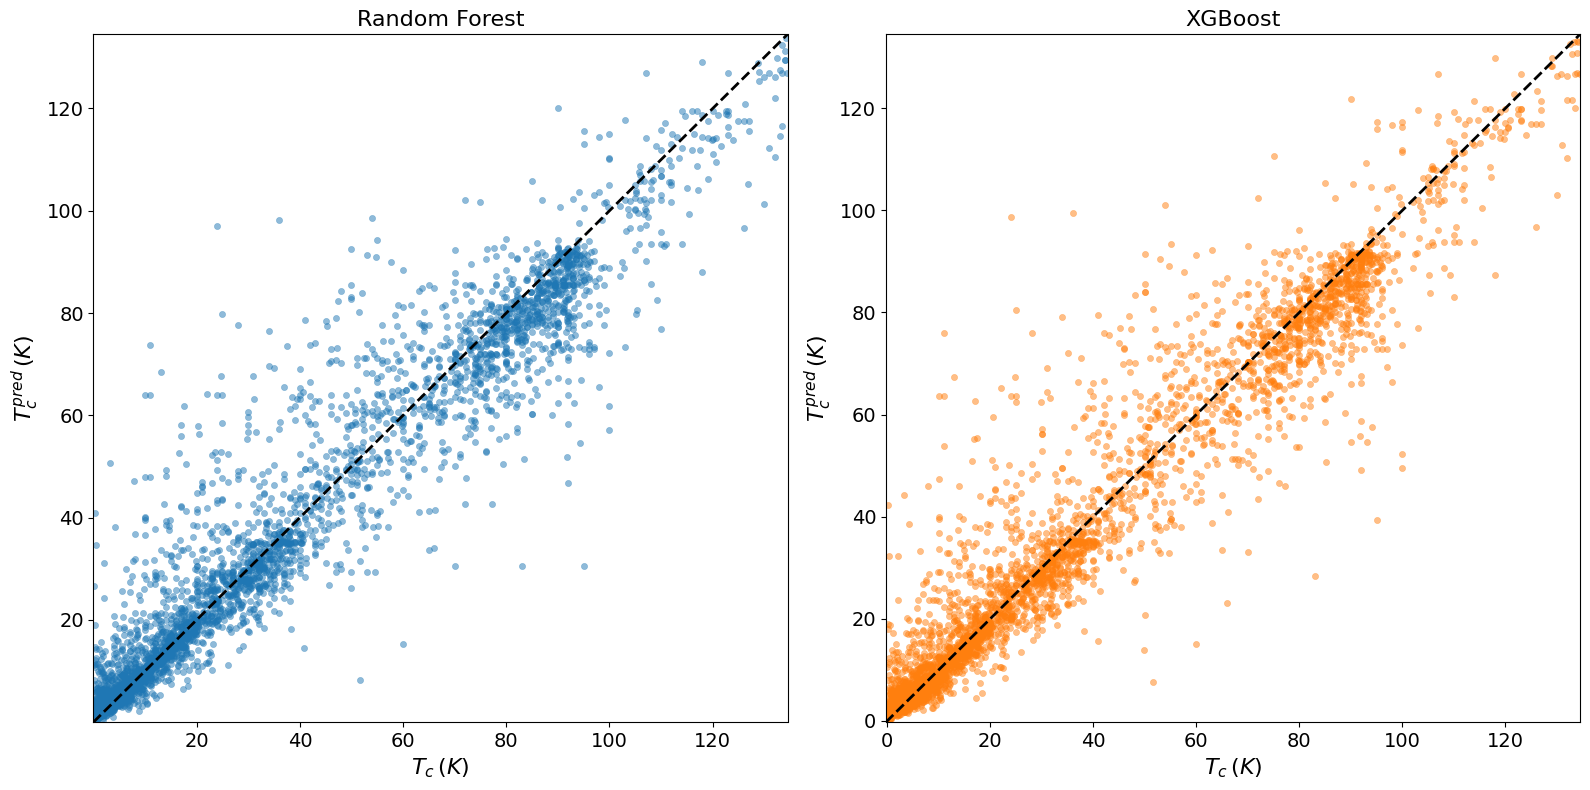

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# --- Random Forest ---
sns.scatterplot(
    x=y_test, y=y_pred_rf_grid,
    ax=axes[0], color="tab:blue", alpha=0.5, s=20, edgecolor=None
)
lims = [min(y_test.min(), y_pred_rf_grid.min()), max(y_test.max(), y_pred_rf_grid.max())]
axes[0].plot(lims, lims, 'k--', lw=2)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_title("Random Forest", fontsize=16)
axes[0].set_xlabel(r"$T_c\,(K)$", fontsize=16)
axes[0].set_ylabel(r"$T_c^{pred}\,(K)$", fontsize=16)

# --- XGBoost ---
sns.scatterplot(
    x=y_test, y=y_pred_xgb_grid,
    ax=axes[1], color="tab:orange", alpha=0.5, s=20, edgecolor=None
)
lims = [min(y_test.min(), y_pred_xgb_grid.min()), max(y_test.max(), y_pred_xgb_grid.max())]
axes[1].plot(lims, lims, 'k--', lw=2)
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_title("XGBoost", fontsize=16)
axes[1].set_xlabel(r"$T_c\,(K)$", fontsize=16)
axes[1].set_ylabel(r"$T_c^{pred}\,(K)$", fontsize=16)

plt.tight_layout()
plt.show()


C:\Users\marco\AppData\Local\Temp\ipykernel_24064\2356046594.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(df_top_importances_rf.index[::-1], fontsize=16)
C:\Users\marco\AppData\Local\Temp\ipykernel_24064\2356046594.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(df_top_importances_xgb.index[::-1], fontsize=16)


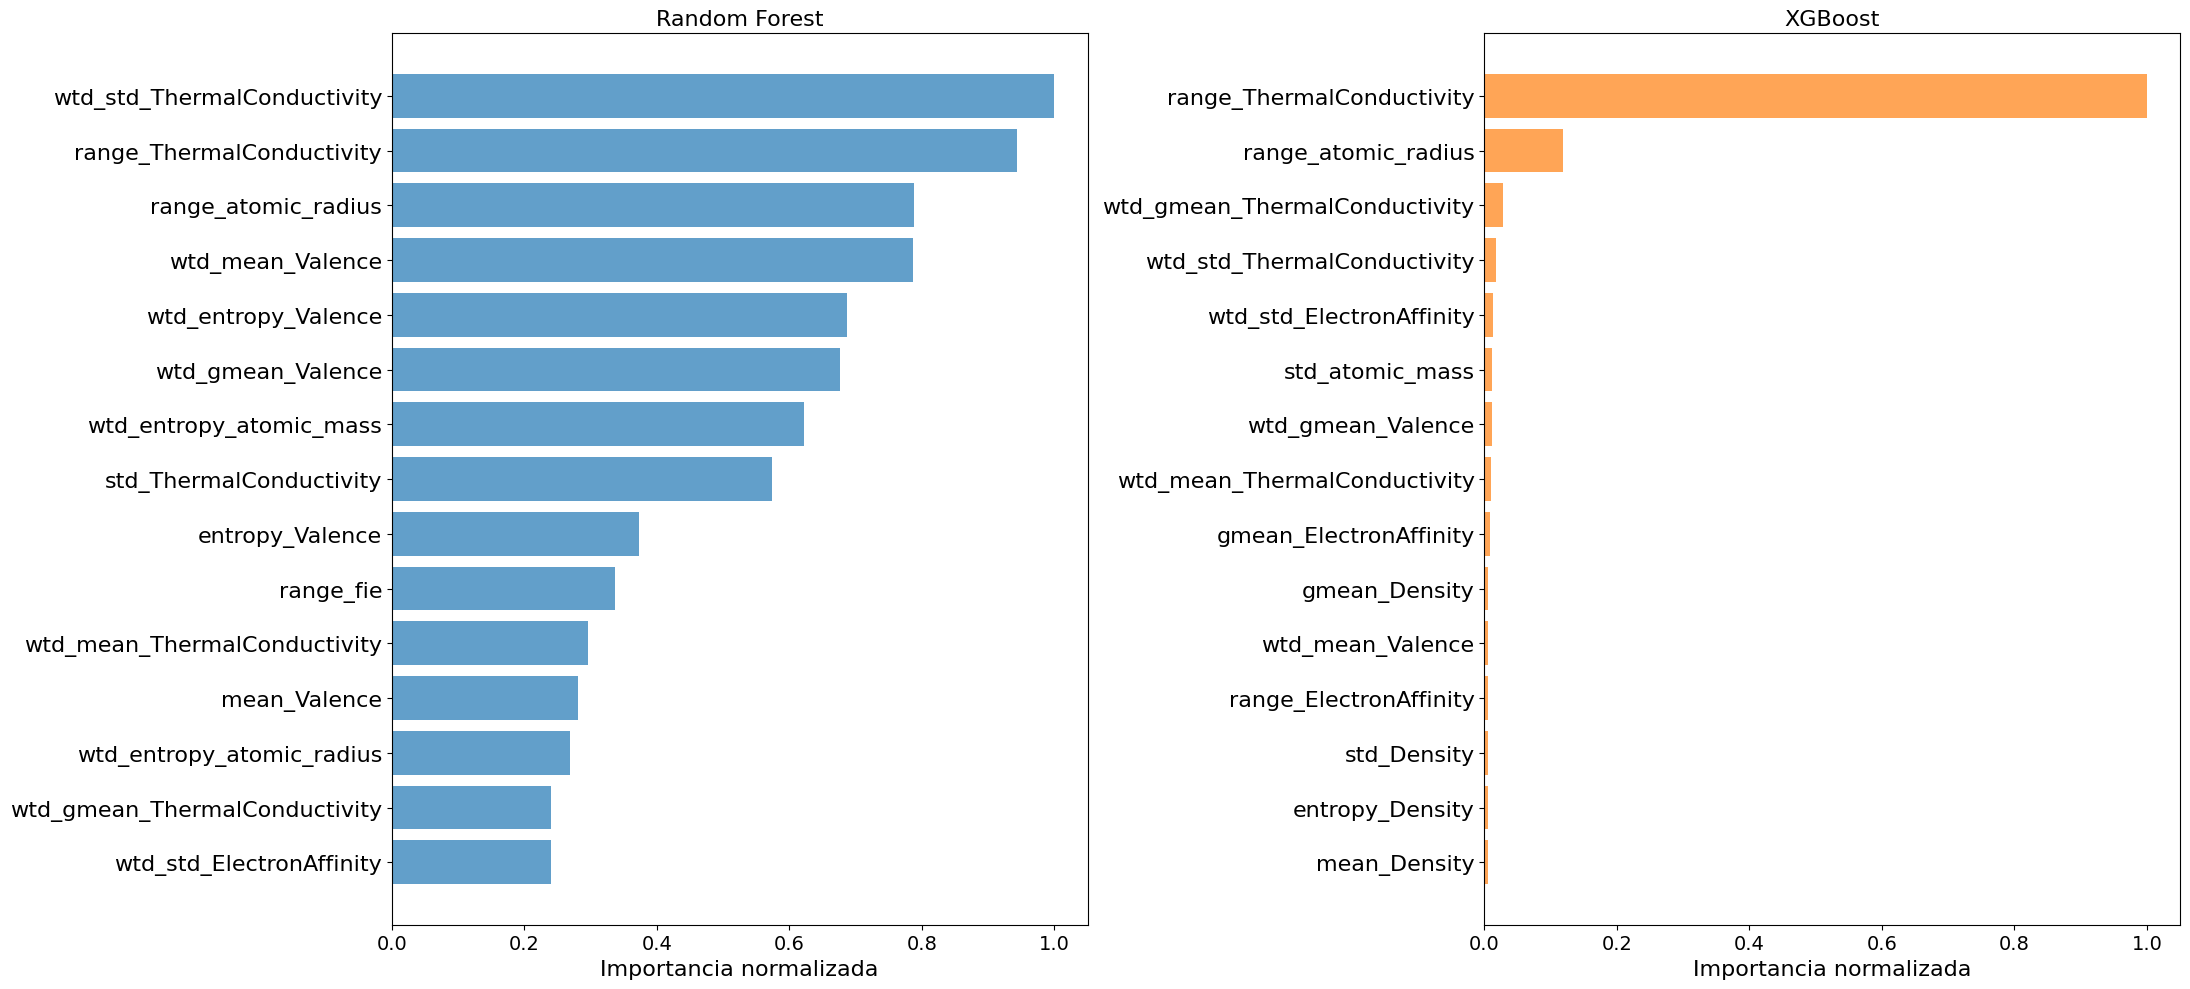

In [81]:
# =============================
# Importancia de características
# =============================

# Extraer importancias
importances_rf_grid = best_rf_grid.feature_importances_
importances_xgb_grid = best_xgb_grid.feature_importances_

# Crear DataFrame comparativo
df_importances_rf = pd.DataFrame({
    "Feature": X.columns,
    "RF_Importance": importances_rf_grid
}).set_index("Feature")

df_importances_xgb = pd.DataFrame({
    "Feature": X.columns,
    "XGB_Importance": importances_xgb_grid
}).set_index("Feature")

# Normalizar (opcional)
df_importances_rf= df_importances_rf / df_importances_rf.max()
df_importances_xgb= df_importances_xgb / df_importances_xgb.max()


# Ordenar por importancia promedio
df_importances_rf = df_importances_rf.sort_values(by="RF_Importance", ascending=False) 
df_importances_xgb = df_importances_xgb.sort_values(by="XGB_Importance", ascending=False) 

# =============================
# Visualización
# =============================

top_n = 15  # número de variables más relevantes
df_top_importances_rf = df_importances_rf.head(top_n)
df_top_importances_xgb = df_importances_xgb.head(top_n)

fig, ax = plt.subplots(1, 2, figsize=(22, 10))

# Random Forest
ax[0].barh(df_top_importances_rf.index[::-1], df_top_importances_rf["RF_Importance"].iloc[::-1], color="tab:blue", alpha=0.7)
ax[0].set_title("Random Forest",fontsize=16)
ax[0].set_xlabel("Importancia normalizada",fontsize=16)
ax[0].set_yticklabels(df_top_importances_rf.index[::-1], fontsize=16)
# XGBoost
ax[1].barh(df_top_importances_xgb.index[::-1], df_top_importances_xgb["XGB_Importance"].iloc[::-1], color="tab:orange", alpha=0.7)
ax[1].set_title("XGBoost", fontsize=16)
ax[1].set_xlabel("Importancia normalizada", fontsize=16)
ax[1].set_yticklabels(df_top_importances_xgb.index[::-1], fontsize=16)

plt.tight_layout()
plt.show()


In [ ]:
#Separamos caracteristicas y variable objetivo
Xd=df.drop(columns=['critical_temp', 'range_ThermalConductivity'])
y=df['critical_temp']

Xd_train, Xd_test, y_train, y_test = train_test_split(
    Xd, y, test_size=0.2, random_state=42
)

print("Train:", Xd_train.shape, "Test:", Xd_test.shape)

Train: (17010, 80) Test: (4253, 80)


In [ ]:
# =============================
# Definición de modelos
# =============================
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=1,
    min_samples_split=5,
    n_estimators= 720
)

xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    colsample_bytree=0.7, 
    learning_rate=0.02,
    max_depth=9,
    n_estimators=800,
    reg_alpha= 0.5,
    reg_lambda=1.0, 
    subsample= 0.9
)

# =============================
# Entrenamiento
# =============================
rf.fit(Xd_train, y_train)
xgb.fit(Xd_train, y_train)

# =============================
# Predicciones
# =============================
y_pred_rf = rf.predict(Xd_test)
y_pred_xgb = xgb.predict(Xd_test)

# =============================
# Métricas
# =============================
def smape(y_true, y_pred):
    return 100/len(y_true) * np.sum(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    )

def safe_mape(y_true, y_pred, eps=10.0):
    mask = y_true > eps
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

results_test = {
    "Random Forest": {
        "R²": r2_score(y_test, y_pred_rf),
        "RMSE": root_mean_squared_error(y_test, y_pred_rf),
        "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred_rf) * 100,
        "sMAPE (%)": smape(y_test, y_pred_rf),
        "safeMAPE (%)": safe_mape(y_test, y_pred_rf)
    },
    "XGBoost": {
        "R²": r2_score(y_test, y_pred_xgb),
        "RMSE": root_mean_squared_error(y_test, y_pred_xgb),
        "MAPE (%)": mean_absolute_percentage_error(y_test, y_pred_xgb) * 100,
        "sMAPE (%)": smape(y_test, y_pred_xgb),
        "safeMAPE (%)": safe_mape(y_test, y_pred_xgb)
    }
}

df_test_results = pd.DataFrame(results_test).T.round(3)
print("Resultados en conjunto de test (escala Kelvin):")
display(df_test_results)

Resultados en conjunto de test (escala Kelvin):


,R²,RMSE,MAPE (%),sMAPE (%),safeMAPE (%)
Random Forest,0.930,8.968,138.951,25.809,18.456
XGBoost,0.934,8.715,121.563,27.661,17.892


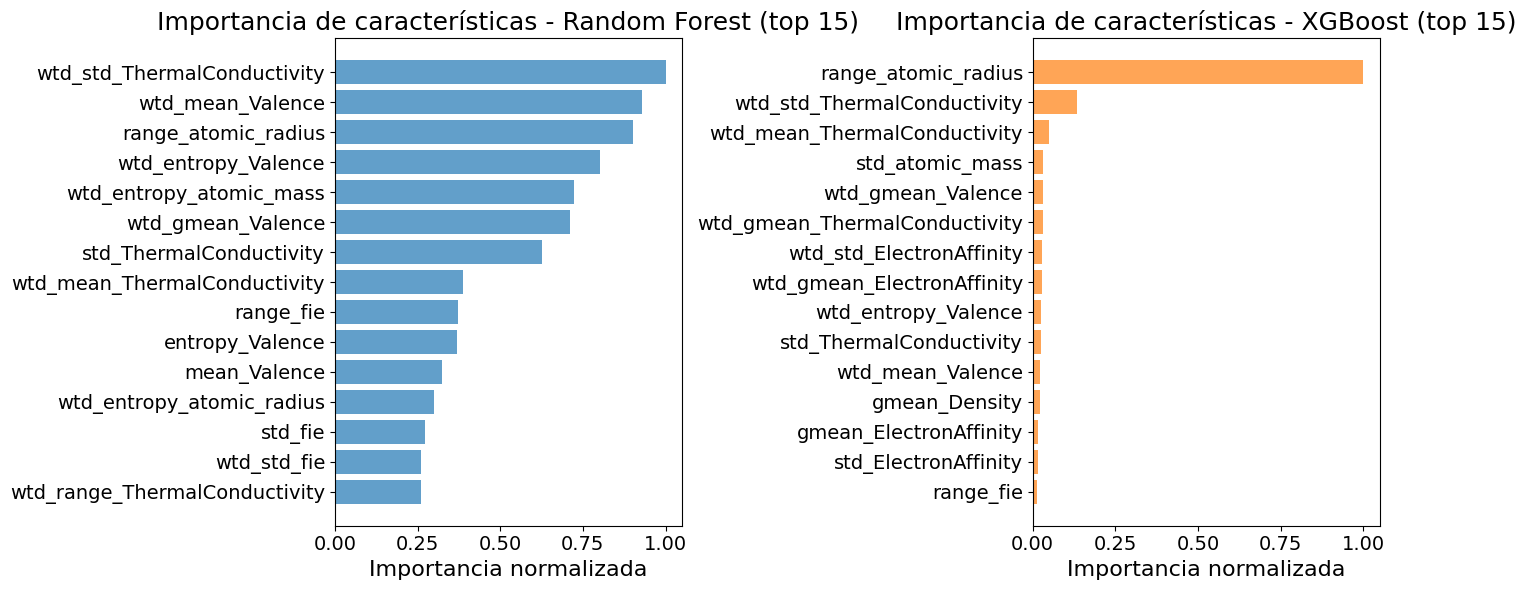

In [ ]:
# =============================
# Importancia de características
# =============================

# Extraer importancias
importances_rf = rf.feature_importances_
importances_xgb= xgb.feature_importances_

# Crear DataFrame comparativo
df_importances_rf = pd.DataFrame({
    "Feature": Xd.columns,
    "RF_Importance": importances_rf
}).set_index("Feature")

df_importances_xgb = pd.DataFrame({
    "Feature": Xd.columns,
    "XGB_Importance": importances_xgb
}).set_index("Feature")

# Normalizar (opcional)
df_importances_rf= df_importances_rf / df_importances_rf.max()
df_importances_xgb= df_importances_xgb / df_importances_xgb.max()


# Ordenar por importancia promedio
df_importances_rf = df_importances_rf.sort_values(by="RF_Importance", ascending=False) 
df_importances_xgb = df_importances_xgb.sort_values(by="XGB_Importance", ascending=False) 

# =============================
# Visualización
# =============================

top_n = 15  # número de variables más relevantes
df_top_importances_rf = df_importances_rf.head(top_n)
df_top_importances_xgb = df_importances_xgb.head(top_n)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
ax[0].barh(df_top_importances_rf.index[::-1], df_top_importances_rf["RF_Importance"].iloc[::-1], color="tab:blue", alpha=0.7)
ax[0].set_title("Importancia de características - Random Forest (top 15)")
ax[0].set_xlabel("Importancia normalizada")

# XGBoost
ax[1].barh(df_top_importances_xgb.index[::-1], df_top_importances_xgb["XGB_Importance"].iloc[::-1], color="tab:orange", alpha=0.7)
ax[1].set_title("Importancia de características - XGBoost (top 15)")
ax[1].set_xlabel("Importancia normalizada")

plt.tight_layout()
plt.show()
